Pri rješavanju AI je korišten za analizu postojećeg koda, prijedloge ispravka pogreške te prijedlog algoritma.

https://chatgpt.com/share/69da63dd-3690-8391-a010-9c46dfc0dc14, https://www.perplexity.ai/search/8ea4eabb-8969-4e26-b30b-22b26604fa69, https://claude.ai/share/1a65d648-9997-4aee-b2ff-443071cd8cae, https://claude.ai/share/cb2b912e-a2df-4bda-895b-c6f2bdd11a2b,

In [ ]:
# analiza podataka
import pandas as pd
import numpy as np

# vizualizacija
import seaborn as sns
import matplotlib.pyplot as plt

# priprema i modeliranje
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB

# evaluacija
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


# Contract data

In [ ]:
FOI_contract_data = pd.read_csv('FOI_contract_data.csv')

In [ ]:
FOI_contract_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79098 entries, 0 to 79097
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CONTRACT_ID             79098 non-null  int64  
 1   VEHICLE_ID              79098 non-null  int64  
 2   OFFER_ID                40095 non-null  float64
 3   CONTRACT_DATE_CREATED   79098 non-null  object 
 4   CONTRACT_LAST_MODIFIED  79098 non-null  object 
 5   CONTRACT_STATUS         79098 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 3.6+ MB


In [ ]:
categorical_cols = FOI_contract_data.select_dtypes(include=['object'])

summary = pd.DataFrame({
    'Varijabla': categorical_cols.columns,
    'Broj_kategorija': [FOI_contract_data[col].nunique() for col in categorical_cols.columns],
})

summary

,Varijabla,Broj_kategorija
0,CONTRACT_DATE_CREATED,79098
1,CONTRACT_LAST_MODIFIED,75758
2,CONTRACT_STATUS,8


In [ ]:
contract_data = FOI_contract_data.copy()

In [ ]:
FOI_contract_data.isna().sum()

,0
CONTRACT_ID,0
VEHICLE_ID,0
OFFER_ID,39003
CONTRACT_DATE_CREATED,0
CONTRACT_LAST_MODIFIED,0
CONTRACT_STATUS,0


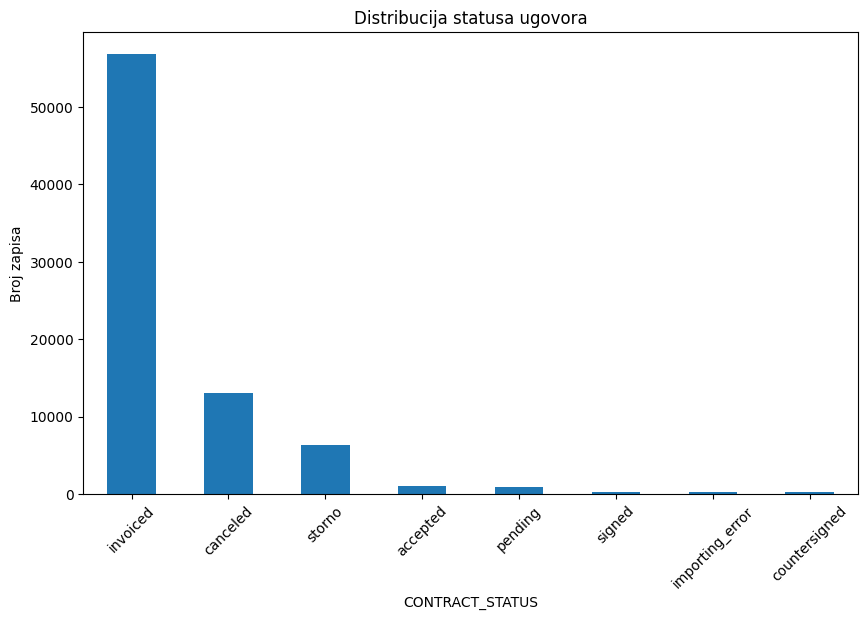

In [ ]:
import matplotlib.pyplot as plt

counts = FOI_contract_data["CONTRACT_STATUS"].value_counts()

plt.figure(figsize=(10, 6))
counts.plot(kind="bar")
plt.title("Distribucija statusa ugovora")
plt.xlabel("CONTRACT_STATUS")
plt.ylabel("Broj zapisa")
plt.xticks(rotation=45)
plt.show()

In [ ]:
FOI_contract_data.duplicated().sum()


np.int64(0)

In [ ]:
contract_data.head()

,CONTRACT_ID,VEHICLE_ID,OFFER_ID,CONTRACT_DATE_CREATED,CONTRACT_LAST_MODIFIED,CONTRACT_STATUS
0,919737,3905213,919358.0,2025-12-15 15:05:19.278,2025-12-15 15:07:59.628,canceled
1,870228,3848608,870225.0,2025-10-03 09:28:02.124,2025-10-06 14:32:47.281,canceled
2,873532,3687497,873523.0,2025-10-08 14:43:26.021,2025-10-09 18:55:56.646,canceled
3,915080,3506204,NaN,2025-12-08 16:05:56.993,2025-12-08 16:06:01.061,invoiced
4,690397,3753246,689649.0,2024-12-17 16:35:21.804,2024-12-23 11:36:24.172,invoiced


In [ ]:
contract_data["CONTRACT_STATUS"].unique()

array(['canceled', 'invoiced', 'storno', 'countersigned', 'pending',
       'accepted', 'importing_error', 'signed'], dtype=object)

In [ ]:
contract_data = contract_data[contract_data["CONTRACT_STATUS"] != 'importing_error']

In [ ]:
contract_data = contract_data[contract_data["CONTRACT_STATUS"] != 'pending']

In [ ]:
desired_statuses = ['invoiced', 'countersigned', 'accepted', 'signed']
contract_data['CONTRACT_STATUS'] = contract_data['CONTRACT_STATUS'].apply(lambda x: 1 if x in desired_statuses else 0)

In [ ]:
contract_data['CONTRACT_DATE_CREATED'] = pd.to_datetime(contract_data['CONTRACT_DATE_CREATED'])
contract_data['CONTRACT_LAST_MODIFIED'] = pd.to_datetime(contract_data['CONTRACT_LAST_MODIFIED'])

In [ ]:
contract_data['CONTRACT_MODIFICATION_DURATION'] = contract_data['CONTRACT_LAST_MODIFIED'] - contract_data['CONTRACT_DATE_CREATED']

In [ ]:
contract_data['CONTRACT_MODIFICATION_DURATION'] = contract_data['CONTRACT_MODIFICATION_DURATION'].dt.days

In [ ]:
contract_data['CONTRACT_DATE_CREATED_IS_WEEKEND'] = contract_data['CONTRACT_DATE_CREATED'].dt.dayofweek.isin([5, 6]).astype(int)
contract_data['CONTRACT_LAST_MODIFIED_IS_WEEKEND'] = contract_data['CONTRACT_LAST_MODIFIED'].dt.dayofweek.isin([5, 6]).astype(int)

In [ ]:
contract_data = contract_data.drop("CONTRACT_DATE_CREATED", axis=1)

In [ ]:
contract_data.head()

,CONTRACT_ID,VEHICLE_ID,OFFER_ID,CONTRACT_LAST_MODIFIED,CONTRACT_STATUS,CONTRACT_MODIFICATION_DURATION,CONTRACT_DATE_CREATED_IS_WEEKEND,CONTRACT_LAST_MODIFIED_IS_WEEKEND
0,919737,3905213,919358.0,2025-12-15 15:07:59.628,0,0,0,0
1,870228,3848608,870225.0,2025-10-06 14:32:47.281,0,3,0,0
2,873532,3687497,873523.0,2025-10-09 18:55:56.646,0,1,0,0
3,915080,3506204,NaN,2025-12-08 16:06:01.061,1,0,0,0
4,690397,3753246,689649.0,2024-12-23 11:36:24.172,1,5,0,0


In [ ]:
contract_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77863 entries, 0 to 79097
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   CONTRACT_ID                        77863 non-null  int64         
 1   VEHICLE_ID                         77863 non-null  int64         
 2   OFFER_ID                           39621 non-null  float64       
 3   CONTRACT_LAST_MODIFIED             77863 non-null  datetime64[ns]
 4   CONTRACT_STATUS                    77863 non-null  int64         
 5   CONTRACT_MODIFICATION_DURATION     77863 non-null  int64         
 6   CONTRACT_DATE_CREATED_IS_WEEKEND   77863 non-null  int64         
 7   CONTRACT_LAST_MODIFIED_IS_WEEKEND  77863 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(6)
memory usage: 5.3 MB


# Offer data


In [ ]:
FOI_offer_data = pd.read_csv('FOI_offer_data.csv')

In [ ]:
FOI_offer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191494 entries, 0 to 191493
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   OFFER_ID             191494 non-null  int64 
 1   VEHICLE_ID           191494 non-null  int64 
 2   LEAD_ID              191494 non-null  int64 
 3   OFFER_DATE_CREATED   191494 non-null  object
 4   OFFER_LAST_MODIFIED  191494 non-null  object
 5   OFFER_STATUS         191494 non-null  object
dtypes: int64(3), object(3)
memory usage: 8.8+ MB


In [ ]:
FOI_offer_data.isna().sum()

,0
OFFER_ID,0
VEHICLE_ID,0
LEAD_ID,0
OFFER_DATE_CREATED,0
OFFER_LAST_MODIFIED,0
OFFER_STATUS,0


In [ ]:
FOI_offer_data.duplicated().sum()


np.int64(0)

In [ ]:
categorical_cols = FOI_offer_data.select_dtypes(include=['object'])

summary = pd.DataFrame({
    'Varijabla': categorical_cols.columns,
    'Broj_kategorija': [FOI_offer_data[col].nunique() for col in categorical_cols.columns],
})

summary

,Varijabla,Broj_kategorija
0,OFFER_DATE_CREATED,191494
1,OFFER_LAST_MODIFIED,190665
2,OFFER_STATUS,4


In [ ]:
offer_data = FOI_offer_data.copy()

In [ ]:
offer_data.head()

,OFFER_ID,VEHICLE_ID,LEAD_ID,OFFER_DATE_CREATED,OFFER_LAST_MODIFIED,OFFER_STATUS
0,867002,3987655,1043531,2025-09-29 09:39:16.253,2025-10-05 00:00:39.371,expired
1,874676,3949220,1041097,2025-10-09 17:59:46.357,2025-10-14 11:06:57.797,completed
2,960003,3900504,1041345,2026-02-14 13:59:27.543,2026-02-14 14:03:12.135,completed
3,864001,3993067,1041061,2025-09-24 14:20:25.783,2025-09-24 15:25:28.897,completed
4,863725,3965900,1040835,2025-09-24 09:51:49.980,2025-09-30 00:01:22.789,expired


In [ ]:
offer_data["OFFER_STATUS"].unique()

array(['expired', 'completed', 'canceled', 'pending'], dtype=object)

In [ ]:
offer_data['OFFER_STATUS'] = offer_data['OFFER_STATUS'].replace({'expired': 'canceled'})

In [ ]:
offer_data['OFFER_DATE_CREATED'] = pd.to_datetime(offer_data['OFFER_DATE_CREATED'])
offer_data['OFFER_LAST_MODIFIED'] = pd.to_datetime(offer_data['OFFER_LAST_MODIFIED'])

In [ ]:
offer_data['OFFER_DURATION'] = offer_data['OFFER_LAST_MODIFIED'] - offer_data['OFFER_DATE_CREATED']

In [ ]:
offer_data['OFFER_DURATION'] = offer_data['OFFER_DURATION'].dt.days

In [ ]:
offer_data['OFFER_DATE_CREATED_IS_WEEKEND'] = offer_data['OFFER_DATE_CREATED'].dt.dayofweek.isin([5, 6]).astype(int)
offer_data['OFFER_LAST_MODIFIED_IS_WEEKEND'] = offer_data['OFFER_LAST_MODIFIED'].dt.dayofweek.isin([5, 6]).astype(int)

In [ ]:
offer_data.head()

,OFFER_ID,VEHICLE_ID,LEAD_ID,OFFER_DATE_CREATED,OFFER_LAST_MODIFIED,OFFER_STATUS,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND
0,867002,3987655,1043531,2025-09-29 09:39:16.253,2025-10-05 00:00:39.371,canceled,5,0,1
1,874676,3949220,1041097,2025-10-09 17:59:46.357,2025-10-14 11:06:57.797,completed,4,0,0
2,960003,3900504,1041345,2026-02-14 13:59:27.543,2026-02-14 14:03:12.135,completed,0,1,1
3,864001,3993067,1041061,2025-09-24 14:20:25.783,2025-09-24 15:25:28.897,completed,0,0,0
4,863725,3965900,1040835,2025-09-24 09:51:49.980,2025-09-30 00:01:22.789,canceled,5,0,0


In [ ]:
offer_data = offer_data.drop("OFFER_DATE_CREATED", axis=1)

In [ ]:
offer_data.head()

,OFFER_ID,VEHICLE_ID,LEAD_ID,OFFER_LAST_MODIFIED,OFFER_STATUS,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND
0,867002,3987655,1043531,2025-10-05 00:00:39.371,canceled,5,0,1
1,874676,3949220,1041097,2025-10-14 11:06:57.797,completed,4,0,0
2,960003,3900504,1041345,2026-02-14 14:03:12.135,completed,0,1,1
3,864001,3993067,1041061,2025-09-24 15:25:28.897,completed,0,0,0
4,863725,3965900,1040835,2025-09-30 00:01:22.789,canceled,5,0,0


In [ ]:
offer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 191494 entries, 0 to 191493
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   OFFER_ID                        191494 non-null  int64         
 1   VEHICLE_ID                      191494 non-null  int64         
 2   LEAD_ID                         191494 non-null  int64         
 3   OFFER_LAST_MODIFIED             191494 non-null  datetime64[ns]
 4   OFFER_STATUS                    191494 non-null  object        
 5   OFFER_DURATION                  191494 non-null  int64         
 6   OFFER_DATE_CREATED_IS_WEEKEND   191494 non-null  int64         
 7   OFFER_LAST_MODIFIED_IS_WEEKEND  191494 non-null  int64         
dtypes: datetime64[ns](1), int64(6), object(1)
memory usage: 11.7+ MB


# Leads data

In [ ]:
FOI_leads_data = pd.read_csv('FOI_leads_data.csv')

In [ ]:
FOI_leads_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37044 entries, 0 to 37043
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   LEAD_ID            37044 non-null  int64 
 1   VEHICLE_ID         37044 non-null  int64 
 2   MARKETPLACE        37044 non-null  object
 3   LEAD_DATE_CREATED  37044 non-null  object
 4   LEAD_STATUS        37044 non-null  object
 5   LEAD_CLOSING_DATE  37044 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.7+ MB


In [ ]:
FOI_leads_data.isna().sum()

,0
LEAD_ID,0
VEHICLE_ID,0
MARKETPLACE,0
LEAD_DATE_CREATED,0
LEAD_STATUS,0
LEAD_CLOSING_DATE,0


In [ ]:
FOI_leads_data.duplicated().sum()


np.int64(0)

In [ ]:
categorical_cols = FOI_leads_data.select_dtypes(include=['object'])

summary = pd.DataFrame({
    'Varijabla': categorical_cols.columns,
    'Broj_kategorija': [FOI_leads_data[col].nunique() for col in categorical_cols.columns],
})

summary

,Varijabla,Broj_kategorija
0,MARKETPLACE,4
1,LEAD_DATE_CREATED,35552
2,LEAD_STATUS,9
3,LEAD_CLOSING_DATE,29858


In [ ]:
leads_data = FOI_leads_data.copy()

In [ ]:
leads_data.head()

,LEAD_ID,VEHICLE_ID,MARKETPLACE,LEAD_DATE_CREATED,LEAD_STATUS,LEAD_CLOSING_DATE
0,1159955,4008168,VehicleHub,2026-01-11 18:35:13.005,contacted,2026-03-04 15:02:16.267
1,1130481,4090063,VehicleHub,2025-12-01 19:45:34.658,contacted,2026-02-09 08:46:24.949
2,1207986,4195607,VehicleHub,2026-02-25 16:53:14.343,contacted,2026-02-26 07:53:03.970
3,1206743,4189287,VehicleHub,2026-02-24 13:59:01.406,contacted,2026-02-24 16:14:53.936
4,1180704,4118691,VehicleHub,2026-01-31 07:02:26.896,contacted,2026-02-12 17:23:37.101


In [ ]:
leads_data["LEAD_STATUS"].unique()

array(['contacted', 'disqualified', 'follow_up', 'manager_lead_pool',
       'dealer_lead_pool', 'won', 'allocated', 'offer', 'contract'],
      dtype=object)

In [ ]:
leads_data['LEAD_STATUS'] = leads_data['LEAD_STATUS'].replace({'contract': 'won', 'manager_lead_pool': 'pool', 'dealer_lead_pool': 'pool', 'offer': 'contacted'})

In [ ]:
leads_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37044 entries, 0 to 37043
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   LEAD_ID            37044 non-null  int64 
 1   VEHICLE_ID         37044 non-null  int64 
 2   MARKETPLACE        37044 non-null  object
 3   LEAD_DATE_CREATED  37044 non-null  object
 4   LEAD_STATUS        37044 non-null  object
 5   LEAD_CLOSING_DATE  37044 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.7+ MB


In [ ]:
leads_data['LEAD_DATE_CREATED'] = pd.to_datetime(leads_data['LEAD_DATE_CREATED'])
leads_data['LEAD_CLOSING_DATE'] = pd.to_datetime(leads_data['LEAD_CLOSING_DATE'])

In [ ]:
leads_data['LEAD_DURATION'] = leads_data['LEAD_CLOSING_DATE'] - leads_data['LEAD_DATE_CREATED']

In [ ]:
leads_data['LEAD_DURATION'] = leads_data['LEAD_DURATION'].dt.days

In [ ]:
leads_data['LEAD_DATE_CREATED_IS_WEEKEND'] = leads_data['LEAD_DATE_CREATED'].dt.dayofweek.isin([5, 6]).astype(int)
leads_data['LEAD_CLOSING_DATE_IS_WEEKEND'] = leads_data['LEAD_CLOSING_DATE'].dt.dayofweek.isin([5, 6]).astype(int)

In [ ]:
leads_data = leads_data.drop("LEAD_DATE_CREATED", axis=1)

In [ ]:
leads_data.head()

,LEAD_ID,VEHICLE_ID,MARKETPLACE,LEAD_STATUS,LEAD_CLOSING_DATE,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND
0,1159955,4008168,VehicleHub,contacted,2026-03-04 15:02:16.267,51,1,0
1,1130481,4090063,VehicleHub,contacted,2026-02-09 08:46:24.949,69,0,0
2,1207986,4195607,VehicleHub,contacted,2026-02-26 07:53:03.970,0,0,0
3,1206743,4189287,VehicleHub,contacted,2026-02-24 16:14:53.936,0,0,0
4,1180704,4118691,VehicleHub,contacted,2026-02-12 17:23:37.101,12,1,0


In [ ]:
leads_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37044 entries, 0 to 37043
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   LEAD_ID                       37044 non-null  int64         
 1   VEHICLE_ID                    37044 non-null  int64         
 2   MARKETPLACE                   37044 non-null  object        
 3   LEAD_STATUS                   37044 non-null  object        
 4   LEAD_CLOSING_DATE             37044 non-null  datetime64[ns]
 5   LEAD_DURATION                 37044 non-null  int64         
 6   LEAD_DATE_CREATED_IS_WEEKEND  37044 non-null  int64         
 7   LEAD_CLOSING_DATE_IS_WEEKEND  37044 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(2)
memory usage: 2.3+ MB


# Publishing data

In [ ]:
FOI_publishing_data = pd.read_csv('FOI_publishing_data.csv')

In [ ]:
FOI_publishing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513937 entries, 0 to 1513936
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   VEHICLE_ID       1513937 non-null  int64  
 1   MARKETPLACE      1513937 non-null  object 
 2   PUBLISH_STATUS   1513937 non-null  object 
 3   DATE_START       1513937 non-null  object 
 4   DATE_END         1513937 non-null  object 
 5   BRAND            1513937 non-null  object 
 6   MODEL            1513937 non-null  object 
 7   MODEL_VERSION    1513934 non-null  object 
 8   BODY_TYPE        1513937 non-null  object 
 9   TRANSMISSION     1513937 non-null  object 
 10  DRIVE_TYPE       1513937 non-null  object 
 11  FUEL_TYPE        1513937 non-null  object 
 12  CO2_EMISSION     1451353 non-null  float64
 13  PRODUCTION_YEAR  1373273 non-null  float64
 14  CURRENT_MILEAGE  1512932 non-null  float64
 15  PRICE            1513897 non-null  float64
dtypes: float64(4), int

In [ ]:
FOI_publishing_data['DATE_START'] = pd.to_datetime(FOI_publishing_data['DATE_START'])
FOI_publishing_data['DATE_END'] = pd.to_datetime(FOI_publishing_data['DATE_END'])
FOI_publishing_data['DURATION_DAYS'] = (FOI_publishing_data['DATE_END'] - FOI_publishing_data['DATE_START']).dt.days

# Display the first few rows with the new column
print(FOI_publishing_data[['DATE_START', 'DATE_END', 'DURATION_DAYS']].head())

               DATE_START                DATE_END  DURATION_DAYS
0 2024-04-05 10:01:23.327 2024-05-06 10:01:23.327             31
1 2024-04-05 10:01:23.327 2024-05-06 10:01:23.327             31
2 2024-06-20 17:19:10.857 2024-07-21 17:19:10.857             31
3 2025-08-08 14:11:41.137 2025-09-08 14:11:41.137             31
4 2024-05-31 07:58:11.033 2024-07-01 07:58:11.033             31


In [ ]:
FOI_publishing_data.isna().sum()

,0
VEHICLE_ID,0
MARKETPLACE,0
PUBLISH_STATUS,0
DATE_START,0
DATE_END,0
BRAND,0
MODEL,0
MODEL_VERSION,3
BODY_TYPE,0
TRANSMISSION,0


In [ ]:
FOI_publishing_data.duplicated().sum()


np.int64(0)

In [ ]:
categorical_cols = FOI_publishing_data.select_dtypes(include=['object'])

summary = pd.DataFrame({
    'Varijabla': categorical_cols.columns,
    'Broj_kategorija': [FOI_publishing_data[col].nunique() for col in categorical_cols.columns],
})

summary

,Varijabla,Broj_kategorija
0,MARKETPLACE,4
1,PUBLISH_STATUS,3
2,BRAND,111
3,MODEL,1336
4,MODEL_VERSION,56760
5,BODY_TYPE,39
6,TRANSMISSION,22
7,DRIVE_TYPE,10
8,FUEL_TYPE,34


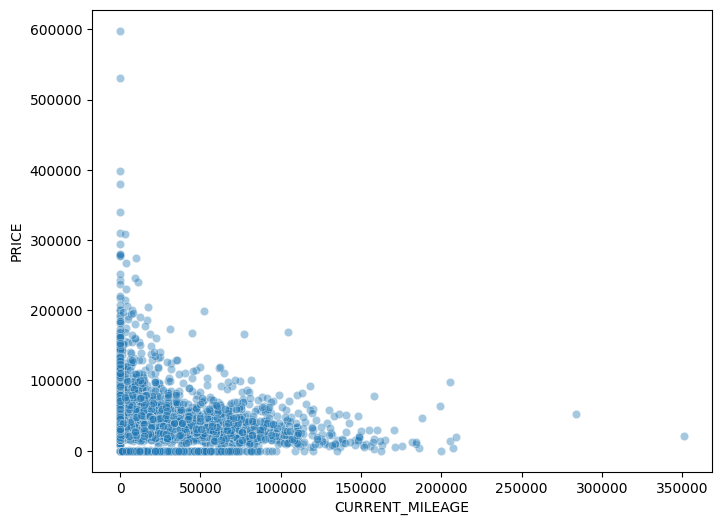

In [ ]:
df_sample = FOI_publishing_data.sample(5000, random_state=42)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_sample,
    x="CURRENT_MILEAGE",
    y="PRICE",
    alpha=0.4
)
plt.show()

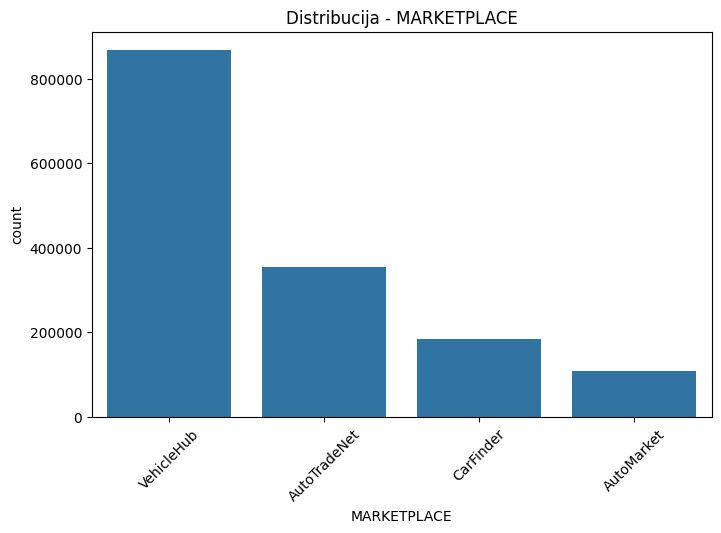

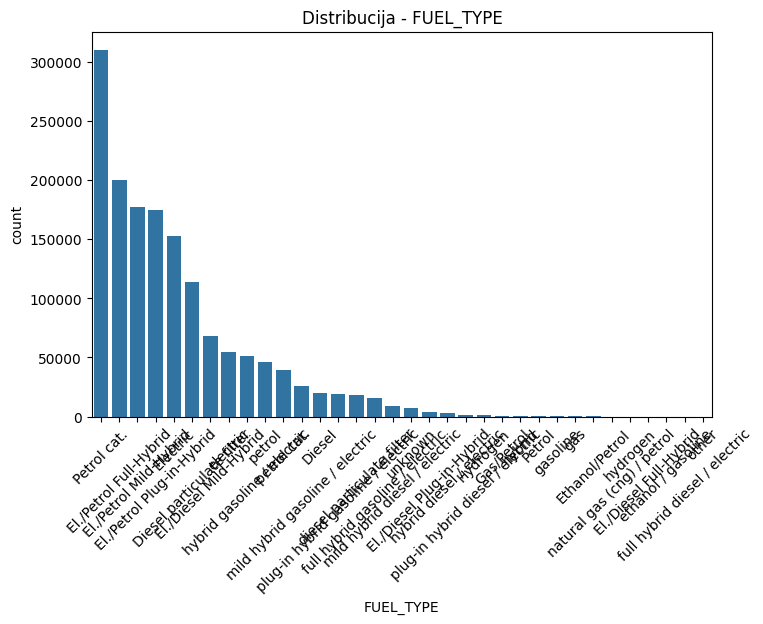

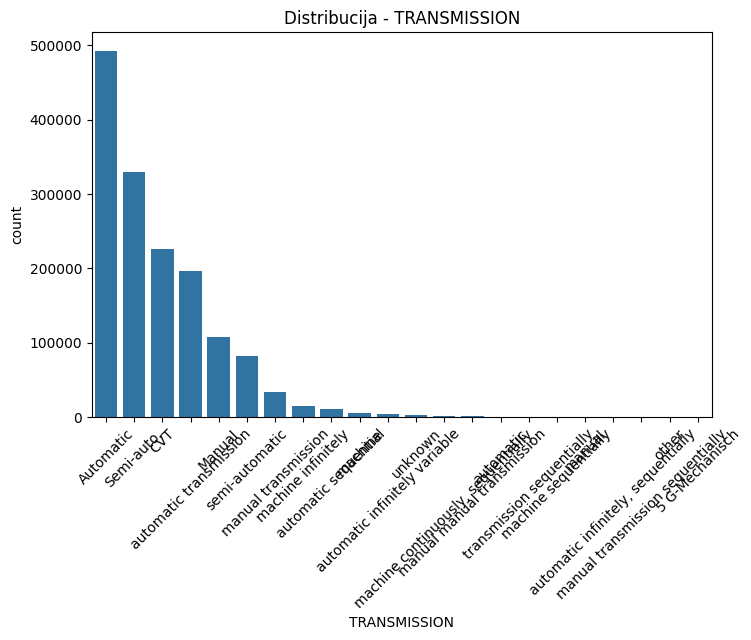

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top_cat_cols = ['MARKETPLACE', 'FUEL_TYPE', 'TRANSMISSION']

for col in top_cat_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=FOI_publishing_data[col], order=FOI_publishing_data[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Distribucija - {col}')
    plt.show()

In [ ]:
numerical_cols = FOI_publishing_data.select_dtypes(include=['int64', 'float64'])

num_summary = numerical_cols.describe().T
num_summary

,count,mean,std,min,25%,50%,75%,max
VEHICLE_ID,1513937.0,3.522143e+06,572641.137417,80698.0,3205356.0,3635185.0,3916249.0,4210271.0
CO2_EMISSION,1451353.0,1.150416e+02,77.737114,0.0,38.0,130.0,163.0,1400.0
PRODUCTION_YEAR,1373273.0,2.022349e+03,15.138138,6.0,2022.0,2023.0,2024.0,2027.0
CURRENT_MILEAGE,1512932.0,2.023582e+04,106217.808921,0.0,21.0,6000.0,26558.0,99999999.0
PRICE,1513897.0,4.702877e+04,330747.675325,-656700.0,26550.0,38900.0,56290.0,99999999.0
DURATION_DAYS,1513937.0,3.092438e+01,0.264396,30.0,31.0,31.0,31.0,31.0


In [ ]:
publishing_data = FOI_publishing_data.copy()

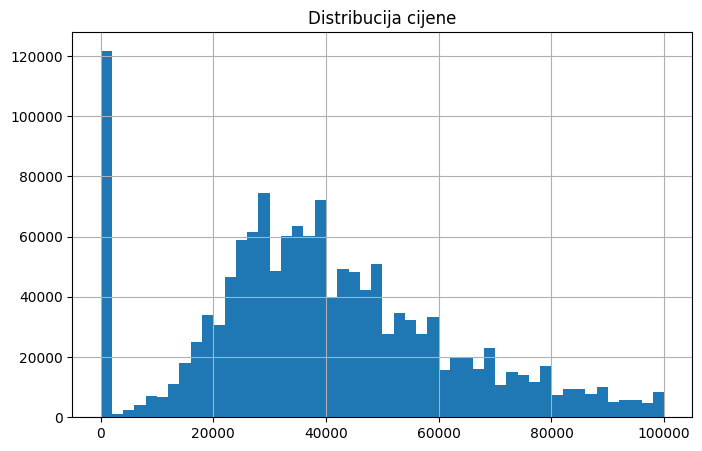

In [ ]:
df_price = FOI_publishing_data[
    (FOI_publishing_data['PRICE'] >= 0) &
    (FOI_publishing_data['PRICE'] <= 100000)
]

plt.figure(figsize=(8,5))
df_price['PRICE'].hist(bins=50)
plt.title("Distribucija cijene")
plt.show()

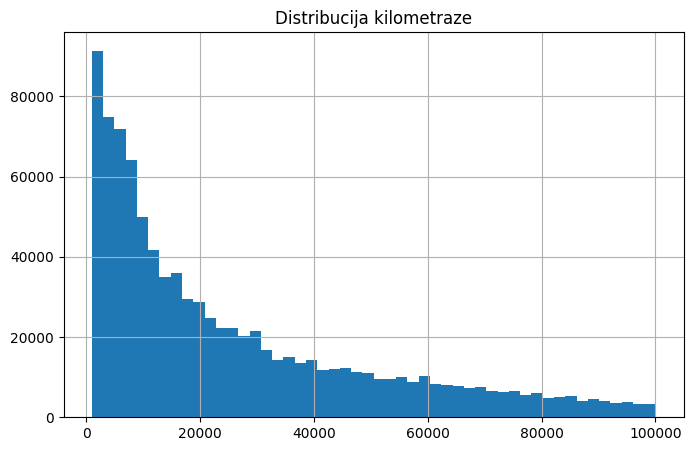

In [ ]:
df_price = FOI_publishing_data[
    (FOI_publishing_data['CURRENT_MILEAGE'] >= 1000) &
    (FOI_publishing_data['CURRENT_MILEAGE'] <= 100000)
]

plt.figure(figsize=(8,5))
df_price['CURRENT_MILEAGE'].hist(bins=50)
plt.title("Distribucija kilometraze")
plt.show()

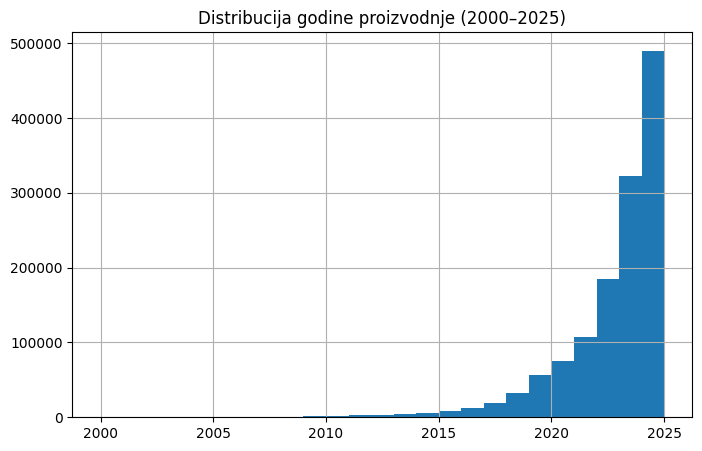

In [ ]:
df_year = FOI_publishing_data[
    (FOI_publishing_data['PRODUCTION_YEAR'] >= 2000) &
    (FOI_publishing_data['PRODUCTION_YEAR'] <= 2025)
]

plt.figure(figsize=(8,5))
df_year['PRODUCTION_YEAR'].hist(bins=25)
plt.title("Distribucija godine proizvodnje (2000–2025)")
plt.show()

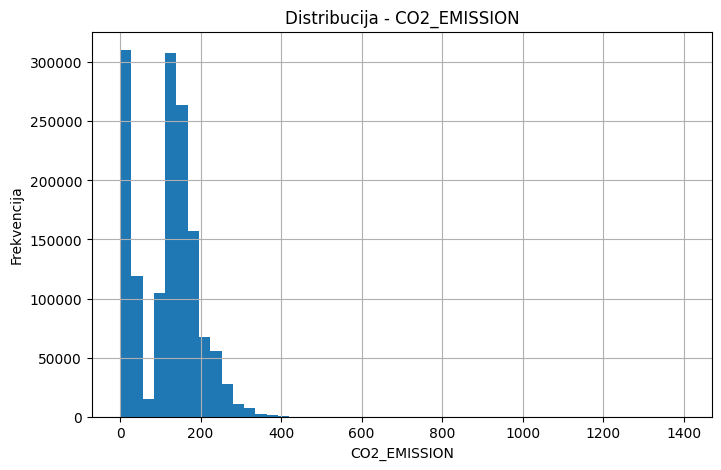

In [ ]:

    plt.figure(figsize=(8,5))
    FOI_publishing_data["CO2_EMISSION"].hist(bins=50)
    plt.title(f'Distribucija - {"CO2_EMISSION"}')
    plt.xlabel("CO2_EMISSION")
    plt.ylabel('Frekvencija')
    plt.show()

In [ ]:
publishing_data.loc[publishing_data['PRODUCTION_YEAR'] <= 1886, 'PRODUCTION_YEAR'] = np.nan

In [ ]:
publishing_data_sorted_by_price = publishing_data.sort_values(by='PRICE', ascending=True)
display(publishing_data_sorted_by_price)

,VEHICLE_ID,MARKETPLACE,PUBLISH_STATUS,DATE_START,DATE_END,BRAND,MODEL,MODEL_VERSION,BODY_TYPE,TRANSMISSION,DRIVE_TYPE,FUEL_TYPE,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS
685994,3276667,VehicleHub,Deactivated,2023-12-07 11:42:49.537,2024-01-07 11:42:49.537,Toyota,Proace City,Proace City Verso L2 50KWh 136PS Trend,large room / van,semi-automatic,front,electric,0.0,2022.0,25.0,-656700.0,31
275418,3502778,VehicleHub,Unpublished,2024-04-16 09:01:46.620,2024-05-17 09:01:46.620,FORD,Transit,Transit Kab.-Ch. 350 L2 2.0 EcoBlue 170 Trail,truck-chassis,manual transmission,front,diesel particulate filter,0.0,2024.0,0.0,-21968.0,31
51013,3256572,VehicleHub,Unpublished,2023-11-13 13:23:58.750,2023-12-14 13:23:58.750,HYUNDAI,Kona,Kona 1.6 T-GDi Vertex 4WD,Off-road vehicle/SUV,Semi-auto.,all_wheel_drive,Petrol cat.,162.0,2024.0,20.0,-20310.0,31
169145,3256572,CarFinder,Unpublished,2023-11-13 13:23:58.777,2023-12-14 13:23:58.777,HYUNDAI,Kona,Kona 1.6 T-GDi Vertex 4WD,Off-road vehicle/SUV,Semi-auto.,all_wheel_drive,Petrol cat.,162.0,2024.0,20.0,-20310.0,31
516258,3854295,VehicleHub,Unpublished,2025-04-03 11:05:19.310,2025-05-04 11:05:19.310,RENAULT,Rafale,Rafale 1.2 E-Tech esprit Alpine,suv / suv,automatic transmission,front,hybrid gasoline / electric,105.0,2025.0,100.0,-1000.0,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1341083,3077209,AutoMarket,Unpublished,2023-07-11 15:44:10.067,2023-08-11 15:44:10.067,Suzuki,Vitara,Vitara 1.4 T Compact Top Hybrid 4x4,Off-road vehicle/SUV,Manual,All-wheel,El./Petrol Mild-Hybrid,136.0,2022.0,500.0,NaN,31
1341647,3077449,VehicleHub,Active,2023-06-13 10:18:51.713,2023-07-14 10:18:51.713,OPEL,Vivaro,Vivaro-e Plattform 2.7 t M 75kWh Essentia,Panel van,Semi-auto.,Front-wheel,Electric,0.0,2022.0,500.0,NaN,31
1358400,3077416,AutoMarket,Unpublished,2023-07-11 15:44:22.900,2023-08-11 15:44:22.900,Suzuki,Across,Across 2.5 PHEV Compact Top 4x4,Off-road vehicle/SUV,CVT,All-wheel,El./Petrol Plug-in-Hybrid,22.0,2023.0,NaN,NaN,31
1370305,3077287,VehicleHub,Active,2023-07-06 09:39:13.870,2023-08-06 09:39:13.870,HONDA,HR-V,HR-V 1.5 i-MMD Advance,Off-road vehicle/SUV,CVT,Front-wheel,El./Petrol Full-Hybrid,122.0,2022.0,2000.0,NaN,31


In [ ]:
publishing_data[publishing_data['PRICE'] < 0]

,VEHICLE_ID,MARKETPLACE,PUBLISH_STATUS,DATE_START,DATE_END,BRAND,MODEL,MODEL_VERSION,BODY_TYPE,TRANSMISSION,DRIVE_TYPE,FUEL_TYPE,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS
51013,3256572,VehicleHub,Unpublished,2023-11-13 13:23:58.750,2023-12-14 13:23:58.750,HYUNDAI,Kona,Kona 1.6 T-GDi Vertex 4WD,Off-road vehicle/SUV,Semi-auto.,all_wheel_drive,Petrol cat.,162.0,2024.0,20.0,-20310.0,31
169145,3256572,CarFinder,Unpublished,2023-11-13 13:23:58.777,2023-12-14 13:23:58.777,HYUNDAI,Kona,Kona 1.6 T-GDi Vertex 4WD,Off-road vehicle/SUV,Semi-auto.,all_wheel_drive,Petrol cat.,162.0,2024.0,20.0,-20310.0,31
275418,3502778,VehicleHub,Unpublished,2024-04-16 09:01:46.620,2024-05-17 09:01:46.620,FORD,Transit,Transit Kab.-Ch. 350 L2 2.0 EcoBlue 170 Trail,truck-chassis,manual transmission,front,diesel particulate filter,0.0,2024.0,0.0,-21968.0,31
516258,3854295,VehicleHub,Unpublished,2025-04-03 11:05:19.310,2025-05-04 11:05:19.310,RENAULT,Rafale,Rafale 1.2 E-Tech esprit Alpine,suv / suv,automatic transmission,front,hybrid gasoline / electric,105.0,2025.0,100.0,-1000.0,31
685994,3276667,VehicleHub,Deactivated,2023-12-07 11:42:49.537,2024-01-07 11:42:49.537,Toyota,Proace City,Proace City Verso L2 50KWh 136PS Trend,large room / van,semi-automatic,front,electric,0.0,2022.0,25.0,-656700.0,31


In [ ]:
import numpy as np

conditions = [
    (publishing_data['PRICE'] < 0) & (publishing_data['PRICE'] >= -50000) & (publishing_data['PRICE'] <= -10000),
    (publishing_data['PRICE'] < 0)
]
choices = [
    publishing_data['PRICE'].abs(),
    np.nan
]
publishing_data['PRICE'] = np.select(conditions, choices, default=publishing_data['PRICE'])
display(publishing_data.head())

,VEHICLE_ID,MARKETPLACE,PUBLISH_STATUS,DATE_START,DATE_END,BRAND,MODEL,MODEL_VERSION,BODY_TYPE,TRANSMISSION,DRIVE_TYPE,FUEL_TYPE,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS
0,3490186,AutoTradeNet,Unpublished,2024-04-05 10:01:23.327,2024-05-06 10:01:23.327,VOLVO,C40,C40 P8 Twin Recharge Ultimate AWD Jetzt von 0....,Saloon,Semi-auto.,All-wheel,Electric,0.0,2023.0,8800.0,38500.0,31
1,3490186,AutoTradeNet,Unpublished,2024-04-05 10:01:23.327,2024-05-06 10:01:23.327,VOLVO,C40,C40 P8 Twin Recharge Ultimate AWD Approfittate...,Saloon,Semi-auto.,All-wheel,Electric,0.0,2023.0,8800.0,38500.0,31
2,3587298,VehicleHub,Unpublished,2024-06-20 17:19:10.857,2024-07-21 17:19:10.857,Lexus,NX,NX 450h+ F-Sport,Off-road vehicle/SUV,CVT,All-wheel,El./Petrol Plug-in-Hybrid,25.0,2023.0,35000.0,71900.0,31
3,3967140,AutoMarket,Unpublished,2025-08-08 14:11:41.137,2025-09-08 14:11:41.137,DAIHATSU,Materia,Materia 1.5 eco-4WD,MPV/Van,Manual,All-wheel,Petrol cat.,172.0,2009.0,215000.0,4200.0,31
4,3298696,AutoTradeNet,Unpublished,2024-05-31 07:58:11.033,2024-07-01 07:58:11.033,Mitsubishi,Space Star,Space Star 1.2 MIVEC Invite,Saloon,CVT,Front-wheel,Petrol cat.,129.0,2023.0,445.0,15900.0,31


In [ ]:
publishing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513937 entries, 0 to 1513936
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   VEHICLE_ID       1513937 non-null  int64         
 1   MARKETPLACE      1513937 non-null  object        
 2   PUBLISH_STATUS   1513937 non-null  object        
 3   DATE_START       1513937 non-null  datetime64[ns]
 4   DATE_END         1513937 non-null  datetime64[ns]
 5   BRAND            1513937 non-null  object        
 6   MODEL            1513937 non-null  object        
 7   MODEL_VERSION    1513934 non-null  object        
 8   BODY_TYPE        1513937 non-null  object        
 9   TRANSMISSION     1513937 non-null  object        
 10  DRIVE_TYPE       1513937 non-null  object        
 11  FUEL_TYPE        1513937 non-null  object        
 12  CO2_EMISSION     1451353 non-null  float64       
 13  PRODUCTION_YEAR  1373197 non-null  float64       
 14  CU

In [ ]:
publishing_data["CURRENT_MILEAGE"].min()

0.0

In [ ]:
publishing_data['CURRENT_MILEAGE'] = publishing_data['CURRENT_MILEAGE'].replace(0, np.nan)

In [ ]:
publishing_data.duplicated().sum()

np.int64(6)

In [ ]:
publishing_data = publishing_data.drop_duplicates()

In [ ]:
publishing_data['PRICE'].isna().sum()

np.int64(42)

In [ ]:
publishing_data.head()

,VEHICLE_ID,MARKETPLACE,PUBLISH_STATUS,DATE_START,DATE_END,BRAND,MODEL,MODEL_VERSION,BODY_TYPE,TRANSMISSION,DRIVE_TYPE,FUEL_TYPE,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS
0,3490186,AutoTradeNet,Unpublished,2024-04-05 10:01:23.327,2024-05-06 10:01:23.327,VOLVO,C40,C40 P8 Twin Recharge Ultimate AWD Jetzt von 0....,Saloon,Semi-auto.,All-wheel,Electric,0.0,2023.0,8800.0,38500.0,31
1,3490186,AutoTradeNet,Unpublished,2024-04-05 10:01:23.327,2024-05-06 10:01:23.327,VOLVO,C40,C40 P8 Twin Recharge Ultimate AWD Approfittate...,Saloon,Semi-auto.,All-wheel,Electric,0.0,2023.0,8800.0,38500.0,31
2,3587298,VehicleHub,Unpublished,2024-06-20 17:19:10.857,2024-07-21 17:19:10.857,Lexus,NX,NX 450h+ F-Sport,Off-road vehicle/SUV,CVT,All-wheel,El./Petrol Plug-in-Hybrid,25.0,2023.0,35000.0,71900.0,31
3,3967140,AutoMarket,Unpublished,2025-08-08 14:11:41.137,2025-09-08 14:11:41.137,DAIHATSU,Materia,Materia 1.5 eco-4WD,MPV/Van,Manual,All-wheel,Petrol cat.,172.0,2009.0,215000.0,4200.0,31
4,3298696,AutoTradeNet,Unpublished,2024-05-31 07:58:11.033,2024-07-01 07:58:11.033,Mitsubishi,Space Star,Space Star 1.2 MIVEC Invite,Saloon,CVT,Front-wheel,Petrol cat.,129.0,2023.0,445.0,15900.0,31


In [ ]:
publishing_data["PUBLISH_STATUS"].unique()

array(['Unpublished', 'Active', 'Deactivated'], dtype=object)

In [ ]:
publishing_data["FUEL_TYPE"].unique()

array(['Electric', 'El./Petrol Plug-in-Hybrid', 'Petrol cat.',
       'El./Petrol Full-Hybrid', 'electric', 'El./Petrol Mild-Hybrid',
       'Diesel particulate filter', 'hybrid gasoline / electric',
       'plug-in hybrid gasoline / electric', 'El./Diesel Mild-Hybrid',
       'full hybrid gasoline / electric', 'petrol', 'unknown', 'Diesel',
       'petrol cat.', 'mild hybrid gasoline / electric',
       'hybrid diesel / electric', 'mild hybrid diesel / electric',
       'El./Diesel Plug-in-Hybrid', 'diesel particulate filter',
       'Hydrogen', 'plug-in hybrid diesel / electric', 'hybrid',
       'gasoline', 'Petrol', 'El./Diesel Full-Hybrid', 'Gas/Petrol',
       'gas', 'hydrogen', 'natural gas (cng) / petrol', 'Ethanol/Petrol',
       'ethanol / gasoline', 'full hybrid diesel / electric', 'other'],
      dtype=object)

In [ ]:
fuel_map = {
    'Petrol': 'Petrol',
    'petrol': 'Petrol',
    'gasoline': 'Petrol',
    'petrol cat.': 'Petrol',
    'Petrol cat.': 'Petrol',

    'Diesel': 'Diesel',
    'Diesel particulate filter': 'Diesel',
    'diesel particulate filter': 'Diesel',

    'Electric': 'Electric',
    'electric': 'Electric',

    'El./Petrol Full-Hybrid': 'Hybrid',
    'full hybrid gasoline / electric': 'Hybrid',
    'hybrid gasoline / electric': 'Hybrid',
    'hybrid': 'Hybrid',

    'El./Petrol Plug-in-Hybrid': 'Plug-in Hybrid',
    'plug-in hybrid gasoline / electric': 'Plug-in Hybrid',
    'plug-in hybrid diesel / electric': 'Plug-in Hybrid',
    'El./Diesel Plug-in-Hybrid': 'Plug-in Hybrid',

    'El./Petrol Mild-Hybrid': 'Mild Hybrid',
    'mild hybrid gasoline / electric': 'Mild Hybrid',
    'mild hybrid diesel / electric': 'Mild Hybrid',
    'El./Diesel Mild-Hybrid': 'Mild Hybrid',

    'gas': 'Gas',
    'Gas/Petrol': 'Gas',
    'natural gas (cng) / petrol': 'Gas',

    'Hydrogen': 'Other',
    'hydrogen': 'Other',
    'unknown': 'Other',
    'other': 'Other'
}

publishing_data['FUEL_TYPE'] = publishing_data['FUEL_TYPE'].map(fuel_map)

In [ ]:
print(FOI_publishing_data['BODY_TYPE'].unique())

['Saloon' 'Off-road vehicle/SUV' 'MPV/Van' 'station wagon' 'Cabriolet'
 'suv / suv' 'Panel van' 'Camper van' 'Sportscar' 'large room / van'
 'Coupé' 'transporter' 'Estate car' 'sedan' 'Off-road vehicle' 'Bus'
 'Delivery van' 'coupe' 'van' 'pick_up' 'Pick-up' 'mpv / minivan'
 'camper van' 'dump_truck' 'Chassis cab' 'truck-chassis' 'largeroomvan'
 'unknown' 'kombi-bus' 'off_road' 'sports car' 'convertible' 'Limousine'
 'Gelaendewagen/Pickup' 'Geländewagen/SUV' 'variant' 'compact' 'other'
 'Keine Zuteilung']


In [ ]:
body_type_map = {
    'Saloon':                'Sedan',
    'Off-road vehicle/SUV':  'SUV',
    'MPV/Van':               'MPV',
    'station wagon':         'Station Wagon',
    'Cabriolet':             'Convertible',
    'suv / suv':             'SUV',
    'Panel van':             'Commercial Vehicle',
    'Camper van':            'Camper Van',
    'Sportscar':             'Sports Car',
    'large room / van':      'Commercial Vehicle',
    'Coupé':                 'Coupe',
    'transporter':           'Commercial Vehicle',
    'Estate car':            'Station Wagon',
    'sedan':                 'Sedan',
    'Off-road vehicle':      'SUV',
    'Bus':                   'Bus',
    'Delivery van':          'Commercial Vehicle',
    'coupe':                 'Coupe',
    'van':                   'Commercial Vehicle',
    'pick_up':               'Pick-up',
    'Pick-up':               'Pick-up',
    'mpv / minivan':         'MPV',
    'camper van':            'Camper Van',
    'dump_truck':            'Pick-up',
    'Chassis cab':           'Commercial Vehicle',
    'truck-chassis':         'Commercial Vehicle',
    'largeroomvan':          'Commercial Vehicle',
    'unknown':               'Unknown',
    'kombi-bus':             'MPV',
    'off_road':              'SUV',
    'sports car':            'Sports Car',
    'convertible':           'Convertible',
    'Limousine':             'Sedan',
    'Gelaendewagen/Pickup':  'SUV',
    'Geländewagen/SUV':      'SUV',
    'variant':               'Station Wagon',
    'compact':               'Sports Car',
    'other':                 'Unknown',
    'Keine Zuteilung':       'Unknown',
}

publishing_data['BODY_TYPE'] = publishing_data['BODY_TYPE'].map(body_type_map)


In [ ]:
publishing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1513931 entries, 0 to 1513936
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   VEHICLE_ID       1513931 non-null  int64         
 1   MARKETPLACE      1513931 non-null  object        
 2   PUBLISH_STATUS   1513931 non-null  object        
 3   DATE_START       1513931 non-null  datetime64[ns]
 4   DATE_END         1513931 non-null  datetime64[ns]
 5   BRAND            1513931 non-null  object        
 6   MODEL            1513931 non-null  object        
 7   MODEL_VERSION    1513928 non-null  object        
 8   BODY_TYPE        1513931 non-null  object        
 9   TRANSMISSION     1513931 non-null  object        
 10  DRIVE_TYPE       1513931 non-null  object        
 11  FUEL_TYPE        1510347 non-null  object        
 12  CO2_EMISSION     1451347 non-null  float64       
 13  PRODUCTION_YEAR  1373191 non-null  float64       
 14  CURRENT

In [ ]:
publishing_data = publishing_data.dropna(subset=['FUEL_TYPE'])

In [ ]:
publishing_data["FUEL_TYPE"].unique()

array(['Electric', 'Plug-in Hybrid', 'Petrol', 'Hybrid', 'Mild Hybrid',
       'Diesel', 'Other', 'Gas'], dtype=object)

In [ ]:
publishing_data.duplicated().sum()

np.int64(3591)

In [ ]:
publishing_data = publishing_data.drop_duplicates()

In [ ]:
publishing_data['MODEL_VERSION'] = publishing_data.groupby('MODEL')['MODEL_VERSION'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x))


In [ ]:
publishing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1506756 entries, 0 to 1513936
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   VEHICLE_ID       1506756 non-null  int64         
 1   MARKETPLACE      1506756 non-null  object        
 2   PUBLISH_STATUS   1506756 non-null  object        
 3   DATE_START       1506756 non-null  datetime64[ns]
 4   DATE_END         1506756 non-null  datetime64[ns]
 5   BRAND            1506756 non-null  object        
 6   MODEL            1506756 non-null  object        
 7   MODEL_VERSION    1506756 non-null  object        
 8   BODY_TYPE        1506756 non-null  object        
 9   TRANSMISSION     1506756 non-null  object        
 10  DRIVE_TYPE       1506756 non-null  object        
 11  FUEL_TYPE        1506756 non-null  object        
 12  CO2_EMISSION     1444190 non-null  float64       
 13  PRODUCTION_YEAR  1366071 non-null  float64       
 14  CURRENT

In [ ]:
mean_co2_by_fuel_type = publishing_data.groupby('FUEL_TYPE')['CO2_EMISSION'].transform(lambda x: x.fillna(x.mean()))
publishing_data['CO2_EMISSION'] = mean_co2_by_fuel_type

In [ ]:
mean_production_year = publishing_data.groupby('MODEL')['PRODUCTION_YEAR'].transform(lambda x: x.fillna(x.mean()))
publishing_data['PRODUCTION_YEAR'] = mean_production_year

In [ ]:
mean_production_year_special = publishing_data.groupby('BRAND')['PRODUCTION_YEAR'].transform(lambda x: x.fillna(x.mean()))
publishing_data['PRODUCTION_YEAR'] = mean_production_year_special

In [ ]:
publishing_data.dropna(subset=['PRODUCTION_YEAR'], inplace=True)

In [ ]:
mean_price = publishing_data.groupby('MODEL')['PRICE'].transform(lambda x: x.fillna(x.mean()))
publishing_data['PRICE'] = mean_price

In [ ]:
mean_mileage = publishing_data.groupby('MODEL')['CURRENT_MILEAGE'].transform(lambda x: x.fillna(x.mean()))
publishing_data['CURRENT_MILEAGE'] = mean_mileage

In [ ]:
publishing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1506724 entries, 0 to 1513936
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   VEHICLE_ID       1506724 non-null  int64         
 1   MARKETPLACE      1506724 non-null  object        
 2   PUBLISH_STATUS   1506724 non-null  object        
 3   DATE_START       1506724 non-null  datetime64[ns]
 4   DATE_END         1506724 non-null  datetime64[ns]
 5   BRAND            1506724 non-null  object        
 6   MODEL            1506724 non-null  object        
 7   MODEL_VERSION    1506724 non-null  object        
 8   BODY_TYPE        1506724 non-null  object        
 9   TRANSMISSION     1506724 non-null  object        
 10  DRIVE_TYPE       1506724 non-null  object        
 11  FUEL_TYPE        1506724 non-null  object        
 12  CO2_EMISSION     1506724 non-null  float64       
 13  PRODUCTION_YEAR  1506724 non-null  float64       
 14  CURRENT

In [ ]:
publishing_data.duplicated().sum()

np.int64(2)

In [ ]:
publishing_data[publishing_data.duplicated(keep =False)]

,VEHICLE_ID,MARKETPLACE,PUBLISH_STATUS,DATE_START,DATE_END,BRAND,MODEL,MODEL_VERSION,BODY_TYPE,TRANSMISSION,DRIVE_TYPE,FUEL_TYPE,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS
220220,3715851,VehicleHub,Unpublished,2024-10-24 16:29:53.530,2024-11-24 15:29:53.530,PEUGEOT,205,205 1.9 GTi,Sedan,Manual,Front-wheel,Petrol,0.0,1987.0,212000.0,14950.0,30
586833,3654449,VehicleHub,Unpublished,2024-08-22 15:04:45.017,2024-09-22 15:04:45.017,OPEL,Signum,Signum 1.9 16V CDTI Diamond,Sedan,automatic transmission,front,Diesel,192.0,2009.0,86000.0,7900.0,31
1059570,3654449,VehicleHub,Unpublished,2024-08-22 15:04:45.017,2024-09-22 15:04:45.017,OPEL,Signum,Signum 1.9 16V CDTI Diamond,Sedan,automatic transmission,front,Diesel,192.0,2009.0,86000.0,7900.0,31
1142770,3715851,VehicleHub,Unpublished,2024-10-24 16:29:53.530,2024-11-24 15:29:53.530,PEUGEOT,205,205 1.9 GTi,Sedan,Manual,Front-wheel,Petrol,0.0,1987.0,212000.0,14950.0,30


In [ ]:
publishing_data = publishing_data.drop_duplicates()

In [ ]:
publishing_data.isna().sum()

,0
VEHICLE_ID,0
MARKETPLACE,0
PUBLISH_STATUS,0
DATE_START,0
DATE_END,0
BRAND,0
MODEL,0
MODEL_VERSION,0
BODY_TYPE,0
TRANSMISSION,0


In [ ]:
publishing_data['DATE_START'] = pd.to_datetime(publishing_data['DATE_START'])
publishing_data['DATE_END'] = pd.to_datetime(publishing_data['DATE_END'])

In [ ]:
publishing_data['DURATION'] = publishing_data['DATE_END'] - publishing_data['DATE_START']

In [ ]:
publishing_data['DURATION'] = publishing_data['DURATION'].dt.days

In [ ]:
publishing_data['DATE_START_IS_WEEKEND'] = publishing_data['DATE_START'].dt.dayofweek.isin([5, 6]).astype(int)
publishing_data['DATE_END_IS_WEEKEND'] = publishing_data['DATE_END'].dt.dayofweek.isin([5, 6]).astype(int)

In [ ]:
publishing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1506722 entries, 0 to 1513936
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VEHICLE_ID             1506722 non-null  int64         
 1   MARKETPLACE            1506722 non-null  object        
 2   PUBLISH_STATUS         1506722 non-null  object        
 3   DATE_START             1506722 non-null  datetime64[ns]
 4   DATE_END               1506722 non-null  datetime64[ns]
 5   BRAND                  1506722 non-null  object        
 6   MODEL                  1506722 non-null  object        
 7   MODEL_VERSION          1506722 non-null  object        
 8   BODY_TYPE              1506722 non-null  object        
 9   TRANSMISSION           1506722 non-null  object        
 10  DRIVE_TYPE             1506722 non-null  object        
 11  FUEL_TYPE              1506722 non-null  object        
 12  CO2_EMISSION           1506722 no

In [ ]:
publishing_data = publishing_data.drop("DATE_END", axis=1)

In [ ]:
publishing_data.duplicated().sum()

np.int64(0)

AKO CE SE IKOM DAT GRUPIRAT SLJEDEĆE: DRIVE_TYPE, TRANSMISSION

In [ ]:
publishing_data['BRAND'] = publishing_data['BRAND'].str.upper()

In [ ]:
brand_map = {
    'FORD USA': 'FORD',
    'CHRYSLER USA': 'CHRYSLER',
    'DODGE USA': 'DODGE',
    'BMW ALPINA': 'BMW',
    'FIAT PROFESSIONAL': 'FIAT'
}

publishing_data['BRAND'] = publishing_data['BRAND'].replace(brand_map)

In [ ]:
publishing_data["BRAND"].unique()

array(['VOLVO', 'LEXUS', 'DAIHATSU', 'MITSUBISHI', 'TOYOTA', 'BMW',
       'OPEL', 'LAND ROVER', 'SUZUKI', 'ASTON MARTIN', 'VW',
       'MERCEDES-BENZ', 'KIA', 'JEEP', 'FORD', 'PEUGEOT', 'CITROEN',
       'FERRARI', 'NISSAN', 'CHEVROLET', 'JAGUAR', 'AUDI', 'VOYAH',
       'MINI', 'MAZDA', 'RENAULT', 'ALFA ROMEO', 'SKODA', 'SUBARU',
       'ZEEKR', 'CUPRA', 'MASERATI', 'HYUNDAI', 'DS', 'BYD', 'HONDA',
       'MG', 'FIAT', 'DACIA', 'PORSCHE', 'PIAGGIO', 'LEAPMOTOR',
       'BENTLEY', 'SEAT', 'SMART', 'KGM', 'ISUZU', 'CADILLAC', 'IVECO',
       'SERES', 'TESLA', 'BAW', 'SSANGYONG', 'LOTUS', 'LANCIA', 'ALPINE',
       'DODGE', 'LAMBORGHINI', 'POLESTAR', 'MAXUS', 'ROLLS ROYCE',
       'GENESIS', 'CHRYSLER', 'JAC', 'XPENG', 'SAAB', 'MCLAREN', 'MAN',
       'DONGFENG', 'PACKARD', 'MORGAN', 'PUCH', 'BAIC', 'INFINITI',
       'INEOS', 'BUGATTI', 'AIWAYS', 'LADA', 'MICRO', 'CROSSCAMP',
       'ELARIS', 'ROVER', 'DFSK', 'SUNBEAM', 'HUMMER', 'WIESMANN',
       'MITSUBISHI FUSO', 'GMC', 'AIXAM', 'B

In [ ]:
publishing_data["DRIVE_TYPE"].unique()

array(['All-wheel', 'Front-wheel', 'all_wheel_drive', 'front',
       'Rear-wheel', 'rear', 'four_wheel_drive', 'unknown', 'all',
       'other'], dtype=object)

In [ ]:
publishing_data['DRIVE_TYPE'] = (publishing_data['DRIVE_TYPE'].str.lower().str.strip())

drive_map = {
    'front-wheel': 'FWD',
    'front': 'FWD',
    'rear-wheel': 'RWD',
    'rear': 'RWD',
    'all-wheel': 'AWD',
    'all_wheel_drive': 'AWD',
    'four_wheel_drive': 'AWD',
    'all': 'AWD',
    'unknown': 'UNKNOWN',
    'other': 'UNKNOWN'
}

publishing_data['DRIVE_TYPE'] = publishing_data['DRIVE_TYPE'].replace(drive_map)
publishing_data['DRIVE_TYPE'] = publishing_data['DRIVE_TYPE'].fillna('UNKNOWN')

In [ ]:
publishing_data["DRIVE_TYPE"].unique()

array(['AWD', 'FWD', 'RWD', 'UNKNOWN'], dtype=object)

In [ ]:
publishing_data['TRANSMISSION'].unique()

array(['Semi-auto.', 'CVT', 'Manual', 'automatic sequential', 'Automatic',
       'automatic transmission', 'manual transmission',
       'machine continuously, sequentially', 'semi-automatic',
       'machine infinitely', 'automatic infinitely variable',
       'manual manual transmission', 'transmission sequentially',
       'machine', 'unknown', 'machine sequentially', 'automatic',
       'manual', 'automatic infinitely, sequentially', '5 G-Mechanisch',
       'manual transmission sequentially', 'other'], dtype=object)

In [ ]:
publishing_data['TRANSMISSION'] = (
    publishing_data['TRANSMISSION']
    .astype(str)
    .str.strip()
)

In [ ]:
publishing_data['TRANSMISSION'].unique()

array(['Semi-auto.', 'CVT', 'Manual', 'automatic sequential', 'Automatic',
       'automatic transmission', 'manual transmission',
       'machine continuously, sequentially', 'semi-automatic',
       'machine infinitely', 'automatic infinitely variable',
       'manual manual transmission', 'transmission sequentially',
       'machine', 'unknown', 'machine sequentially', 'automatic',
       'manual', 'automatic infinitely, sequentially', '5 G-Mechanisch',
       'manual transmission sequentially', 'other'], dtype=object)

In [ ]:
transmission_map = {
    # Manual
    'Manual': 'Manual',
    'manual': 'Manual',
    'manual transmission': 'Manual',
    'manual manual transmission': 'Manual',
    '5 G-Mechanisch': 'Manual',

    # Automatic
    'Automatic': 'Automatic',
    'automatic': 'Automatic',
    'automatic transmission': 'Automatic',
    'machine': 'Automatic',
    'machine infinitely': 'Automatic',
    'automatic infinitely variable': 'Automatic',

    # CVT
    'CVT': 'CVT',
    'automatic infinitely, sequentially': 'CVT',

    # Semi-Automatic
    'Semi-auto.': 'Semi-Automatic',
    'semi-automatic': 'Semi-Automatic',
    'automatic sequential': 'Semi-Automatic',
    'transmission sequentially': 'Semi-Automatic',
    'machine sequentially': 'Semi-Automatic',
    'manual transmission sequentially': 'Semi-Automatic',
    'machine continuously, sequentially': 'Semi-Automatic',

    # Other
    'unknown': 'Other',
    'other': 'Other'
}

In [ ]:
original_transmissions = set(publishing_data['TRANSMISSION'].dropna().unique())
mapped_transmissions = set(transmission_map.keys())

unmapped_transmissions = original_transmissions - mapped_transmissions
print(unmapped_transmissions)

set()


In [ ]:
publishing_data['TRANSMISSION'] = publishing_data['TRANSMISSION'].map(transmission_map)

In [ ]:
publishing_data['TRANSMISSION'].value_counts(dropna=False)

,count
TRANSMISSION,
Automatic,710213
Semi-Automatic,425150
CVT,225095
Manual,143404
Other,2860


In [ ]:
publishing_data['TRANSMISSION'].isna().sum()

np.int64(0)

In [ ]:
publishing_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1506722 entries, 0 to 1513936
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   VEHICLE_ID             1506722 non-null  int64         
 1   MARKETPLACE            1506722 non-null  object        
 2   PUBLISH_STATUS         1506722 non-null  object        
 3   DATE_START             1506722 non-null  datetime64[ns]
 4   BRAND                  1506722 non-null  object        
 5   MODEL                  1506722 non-null  object        
 6   MODEL_VERSION          1506722 non-null  object        
 7   BODY_TYPE              1506722 non-null  object        
 8   TRANSMISSION           1506722 non-null  object        
 9   DRIVE_TYPE             1506722 non-null  object        
 10  FUEL_TYPE              1506722 non-null  object        
 11  CO2_EMISSION           1506722 non-null  float64       
 12  PRODUCTION_YEAR        1506722 no

In [ ]:
publishing_data.duplicated().sum()

np.int64(41832)

In [ ]:
publishing_data = publishing_data.drop_duplicates()

# Stršila

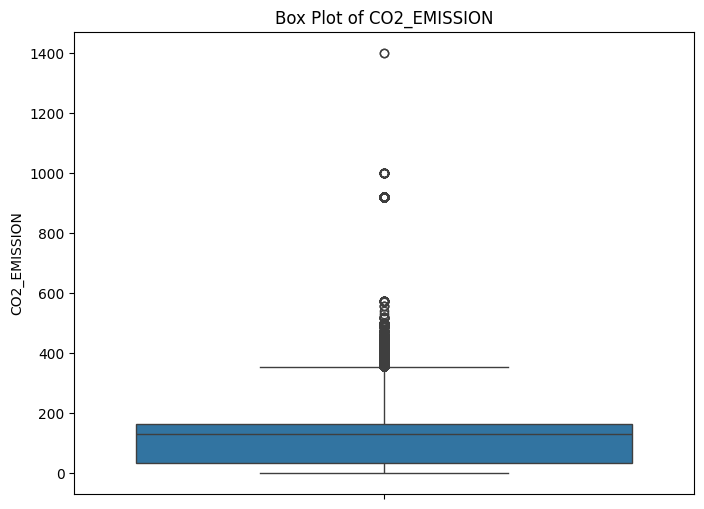

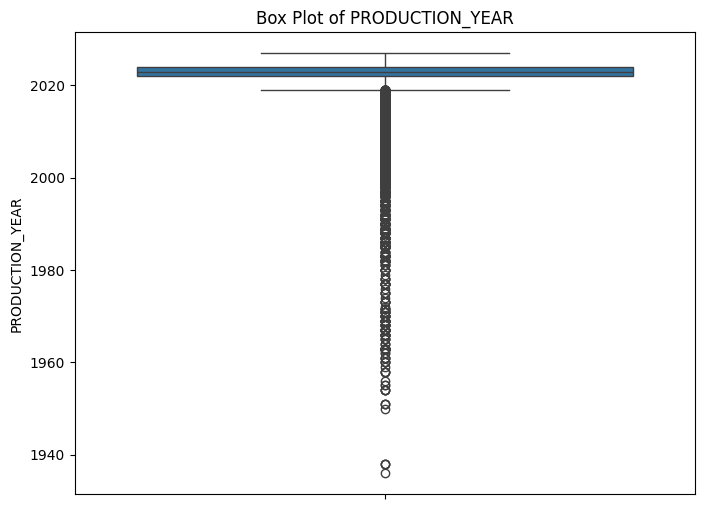

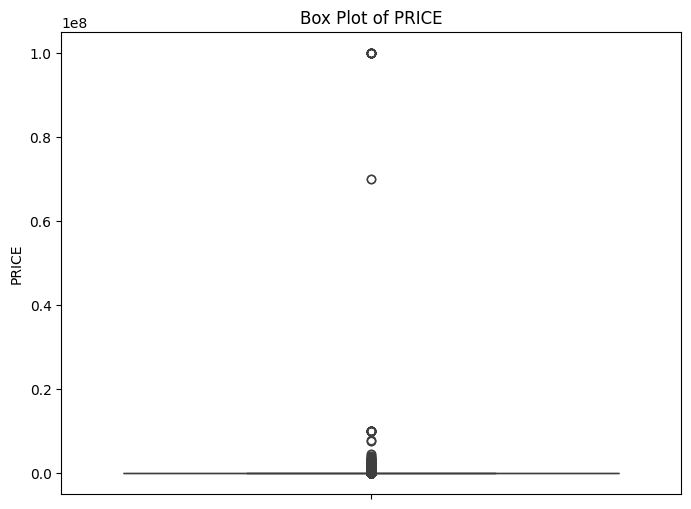

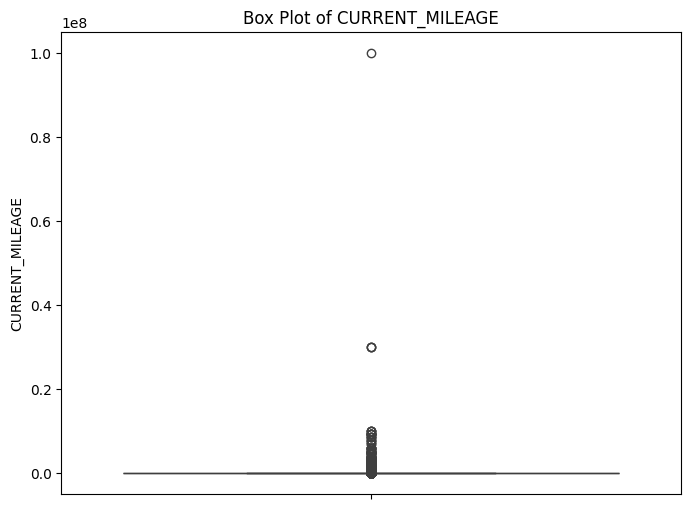

In [ ]:
numerical_cols_publishing = publishing_data[["CO2_EMISSION", "PRODUCTION_YEAR", "PRICE", "CURRENT_MILEAGE"]]

for col in numerical_cols_publishing:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=publishing_data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

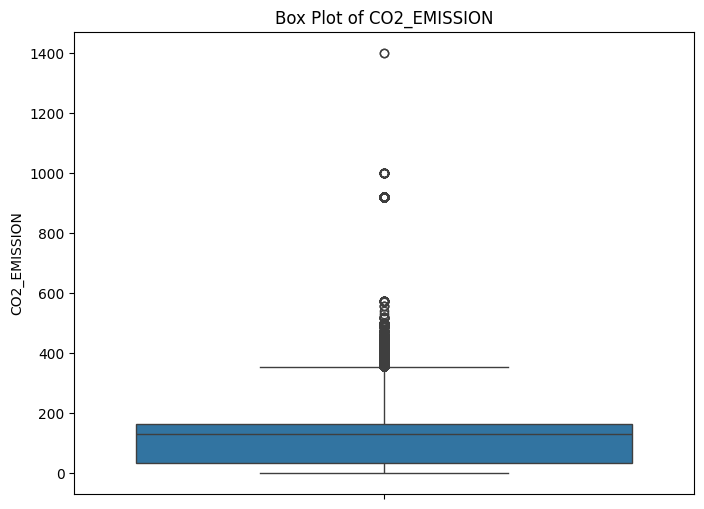

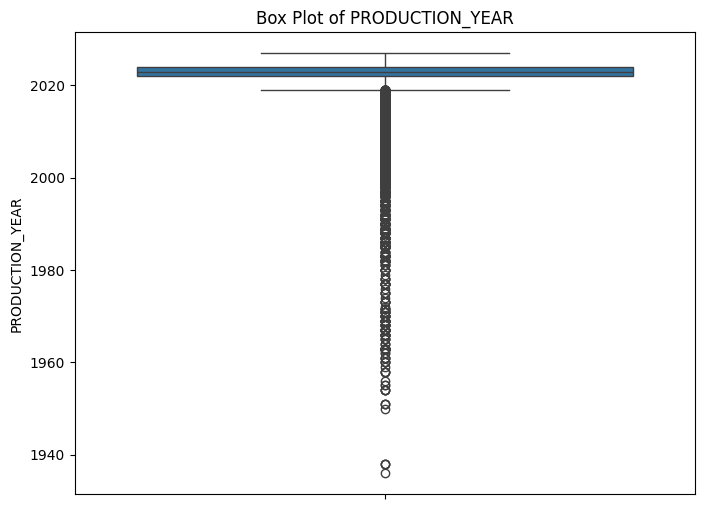

In [ ]:
numerical_cols_publishing = publishing_data[["CO2_EMISSION", "PRODUCTION_YEAR"]]

for col in numerical_cols_publishing:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=publishing_data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [ ]:
df = publishing_data.copy()

In [ ]:
df = publishing_data[publishing_data['CO2_EMISSION'] <= 400]

In [ ]:
df = publishing_data[publishing_data['PRODUCTION_YEAR'] >= 1985]

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df[df['PRICE'].between(1000, 80000)]

median_price = (
    df.groupby(['BRAND', 'MODEL'])['PRICE']
    .median()
    .reset_index()
    .rename(columns={'PRICE': 'PRICE_median'})
)

df = df.merge(median_price, on=['BRAND', 'MODEL'], how='left')
df['price_ratio'] = df['PRICE'] / df['PRICE_median']
df_clean = df[df['price_ratio'].between(0.3, 3)]

removed = len(df) - len(df_clean)
print(removed / len(df) * 100)

0.7930386234852963


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["PRICE"].max()

80000.0

In [ ]:
# median kilometraža po brandu, modelu i godini
median_mileage = (
    df_clean
    .groupby(['BRAND','MODEL','PRODUCTION_YEAR'])['CURRENT_MILEAGE']
    .median()
    .reset_index()
    .rename(columns={'CURRENT_MILEAGE': 'MILEAGE_median'})
)

# merge nazad u dataset
df_clean = df_clean.merge(
    median_mileage,
    on=['BRAND','MODEL','PRODUCTION_YEAR'],
    how='left'
)

# izračun omjera kilometraže
df_clean['mileage_ratio'] = df_clean['CURRENT_MILEAGE'] / df_clean['MILEAGE_median']

# filtriranje normalnih vrijednosti
df_clean = df_clean[
    df_clean['mileage_ratio'].between(0.2, 5)
]

In [ ]:
current_year = 2025

df_clean['AGE'] = current_year - df_clean['PRODUCTION_YEAR']

df_clean = df_clean[
    (df_clean['CURRENT_MILEAGE'] >= 0) &
    (df_clean['CURRENT_MILEAGE'] <= df_clean['AGE'] * 30000 + 20000) &
    (df_clean['CURRENT_MILEAGE'] <= 400000)
]

In [ ]:
df_clean.max()

,0
VEHICLE_ID,4210194
MARKETPLACE,VehicleHub
PUBLISH_STATUS,Unpublished
DATE_START,2026-02-28 18:28:24.827000
BRAND,ZEEKR
MODEL,ë-C5 Aircross Max
MODEL_VERSION,ë-Spacetourer M 75 kWh Business Lounge
BODY_TYPE,Unknown
TRANSMISSION,Semi-Automatic
DRIVE_TYPE,UNKNOWN


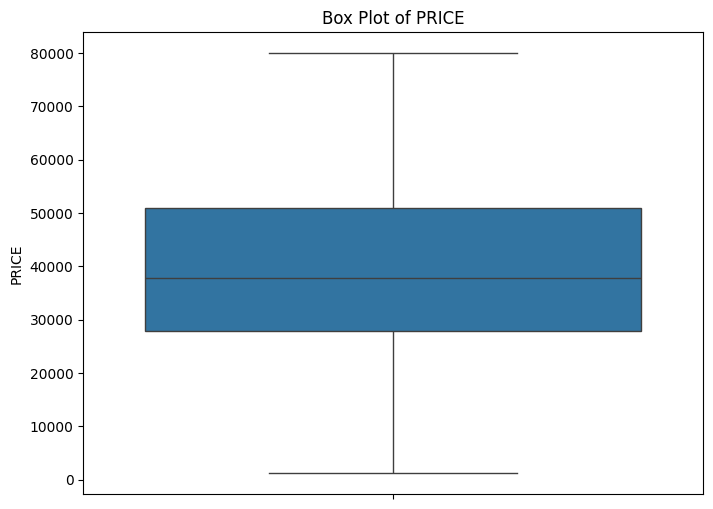

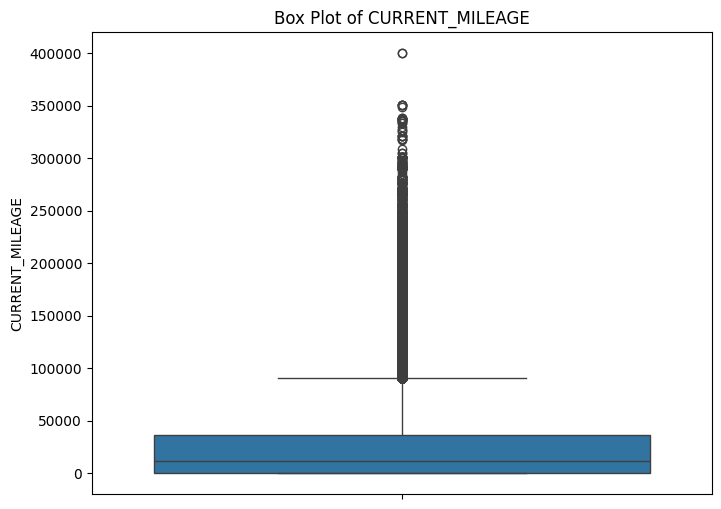

In [ ]:
numerical_cols_publishing = df_clean[["PRICE", "CURRENT_MILEAGE"]]

for col in numerical_cols_publishing:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_clean[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

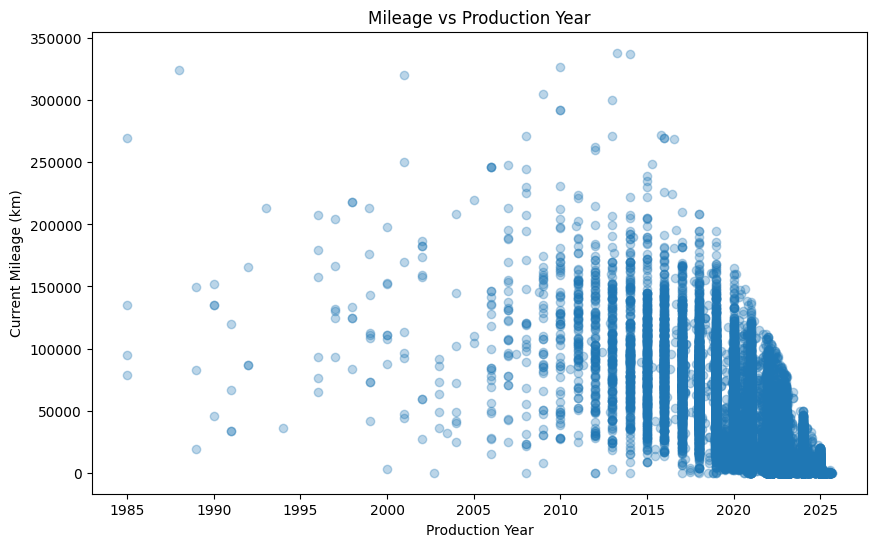

In [ ]:
import matplotlib.pyplot as plt

# uzmi manji sample da graf bude čitljiv
df_sample = df_clean.sample(50000, random_state=42)

plt.figure(figsize=(10,6))

plt.scatter(
    df_sample['PRODUCTION_YEAR'],
    df_sample['CURRENT_MILEAGE'],
    alpha=0.3
)

plt.xlabel("Production Year")
plt.ylabel("Current Mileage (km)")
plt.title("Mileage vs Production Year")

plt.show()

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 801619 entries, 0 to 1188423
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VEHICLE_ID             801619 non-null  int64         
 1   MARKETPLACE            801619 non-null  object        
 2   PUBLISH_STATUS         801619 non-null  object        
 3   DATE_START             801619 non-null  datetime64[ns]
 4   BRAND                  801619 non-null  object        
 5   MODEL                  801619 non-null  object        
 6   MODEL_VERSION          801619 non-null  object        
 7   BODY_TYPE              801619 non-null  object        
 8   TRANSMISSION           801619 non-null  object        
 9   DRIVE_TYPE             801619 non-null  object        
 10  FUEL_TYPE              801619 non-null  object        
 11  CO2_EMISSION           801619 non-null  float64       
 12  PRODUCTION_YEAR        801619 non-null  float64 

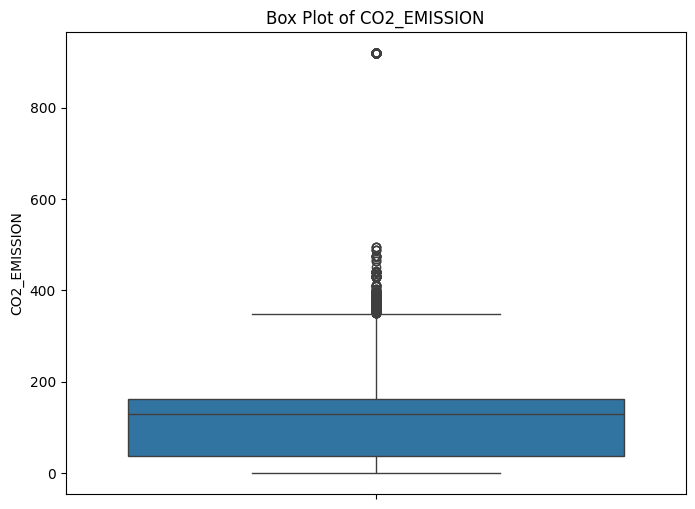

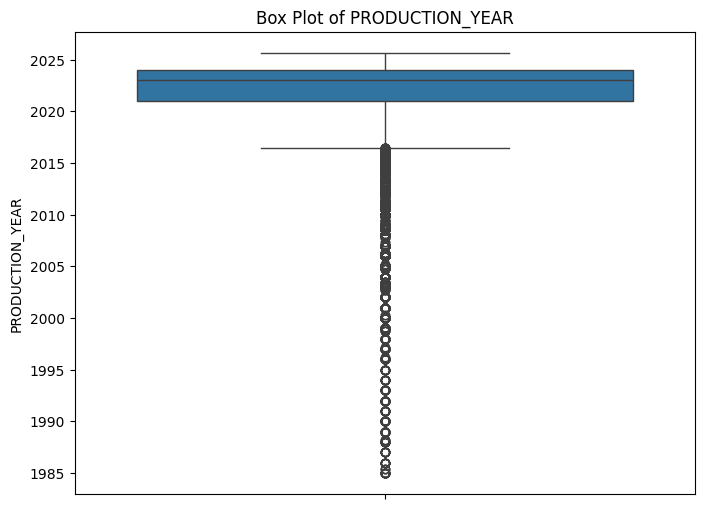

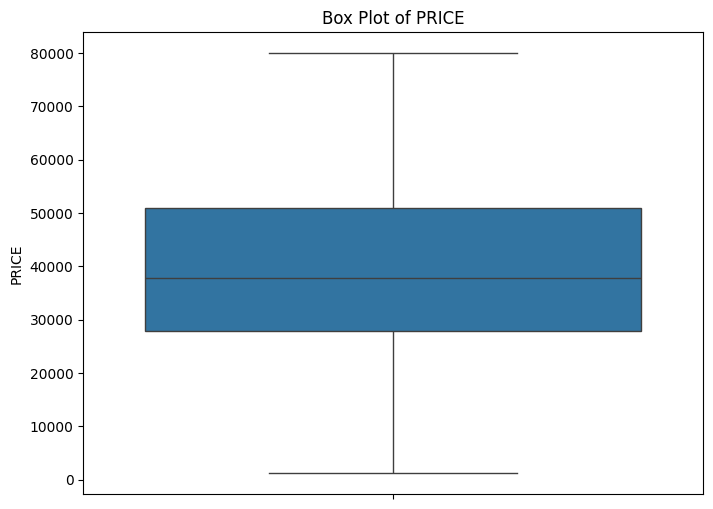

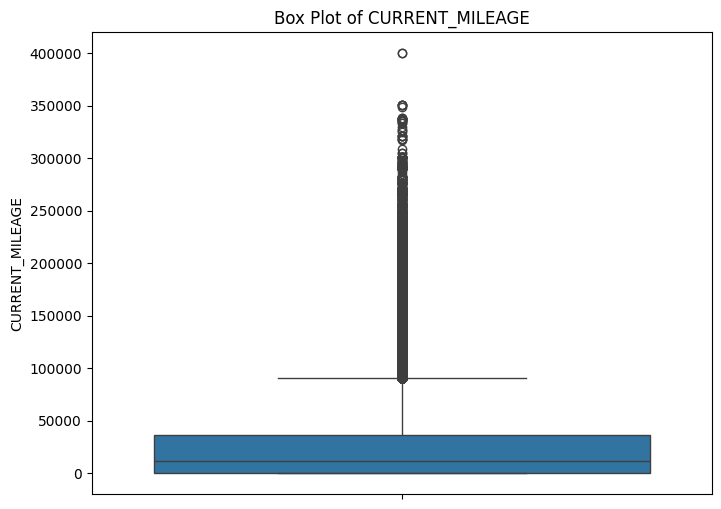

In [ ]:
numerical_cols_publishing = df_clean[["CO2_EMISSION", "PRODUCTION_YEAR", "PRICE", "CURRENT_MILEAGE"]]

for col in numerical_cols_publishing:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_clean[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [ ]:
df_clean["CURRENT_MILEAGE"].min()

1.0

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

# Merge

In [ ]:
df_clean.isna().sum()

,0
VEHICLE_ID,0
MARKETPLACE,0
PUBLISH_STATUS,0
DATE_START,0
BRAND,0
MODEL,0
MODEL_VERSION,0
BODY_TYPE,0
TRANSMISSION,0
DRIVE_TYPE,0


In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_merged = pd.merge(df_clean, contract_data, on="VEHICLE_ID", how="left")

In [ ]:
df_merged = pd.merge(df_merged, offer_data, on="OFFER_ID", how="left")

In [ ]:
df_merged = pd.merge(df_merged, leads_data, on="LEAD_ID", how="left")

In [ ]:
df_merged.duplicated().sum()

np.int64(0)

In [ ]:
df_merged.isna().sum()

,0
VEHICLE_ID_x,0
MARKETPLACE_x,0
PUBLISH_STATUS,0
DATE_START,0
BRAND,0
MODEL,0
MODEL_VERSION,0
BODY_TYPE,0
TRANSMISSION,0
DRIVE_TYPE,0


In [ ]:
df_merged.drop(columns=["VEHICLE_ID_y", "MARKETPLACE_y", "VEHICLE_ID_x"], inplace=True)

In [ ]:
df_merged[df_merged.duplicated()]

,MARKETPLACE_x,PUBLISH_STATUS,DATE_START,BRAND,MODEL,MODEL_VERSION,BODY_TYPE,TRANSMISSION,DRIVE_TYPE,FUEL_TYPE,...,OFFER_STATUS,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND,VEHICLE_ID,LEAD_STATUS,LEAD_CLOSING_DATE,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND
129409,VehicleHub,Active,2026-02-18 16:07:56.797,VOLVO,EX40,EX40 Twin Ultra AWD XCENTRIC,SUV,Automatic,AWD,Electric,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
531911,VehicleHub,Active,2026-02-05 11:59:01.653,VOLVO,EX40,EX40 Twin Ultra AWD XCENTRIC,SUV,Automatic,AWD,Electric,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
748356,VehicleHub,Active,2026-02-05 11:59:01.653,VOLVO,EX40,EX40 Twin Ultra AWD XCENTRIC,SUV,Automatic,AWD,Electric,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
920681,VehicleHub,Unpublished,2025-07-24 09:31:32.383,FIAT,Scudo,Scudo Kaw. L3 1.5 BlueHDI 120,Commercial Vehicle,Manual,FWD,Diesel,...,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN


In [ ]:
df_merged.rename(columns={"MARKETPLACE_x": "MARKETPLACE"}, inplace=True)


In [ ]:
df_merged.duplicated().sum()

np.int64(4)

In [ ]:
df_merged.drop(columns=["VEHICLE_ID", "PRICE_median", "price_ratio", "MILEAGE_median", "mileage_ratio", "CONTRACT_ID", "OFFER_ID", "LEAD_ID"], inplace=True)

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 932406 entries, 0 to 932405
Data columns (total 34 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   MARKETPLACE                        932406 non-null  object        
 1   PUBLISH_STATUS                     932406 non-null  object        
 2   DATE_START                         932406 non-null  datetime64[ns]
 3   BRAND                              932406 non-null  object        
 4   MODEL                              932406 non-null  object        
 5   MODEL_VERSION                      932406 non-null  object        
 6   BODY_TYPE                          932406 non-null  object        
 7   TRANSMISSION                       932406 non-null  object        
 8   DRIVE_TYPE                         932406 non-null  object        
 9   FUEL_TYPE                          932406 non-null  object        
 10  CO2_EMISSION        

In [ ]:
df_merged = df_merged.drop_duplicates()

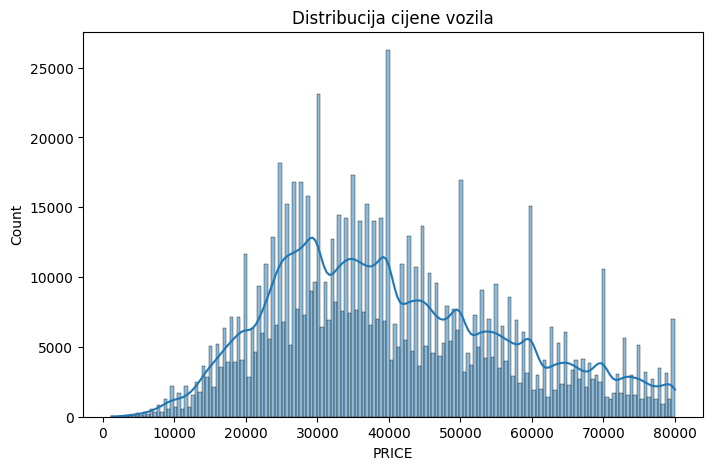

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_merged["PRICE"], kde=True)
plt.title("Distribucija cijene vozila")
plt.show()

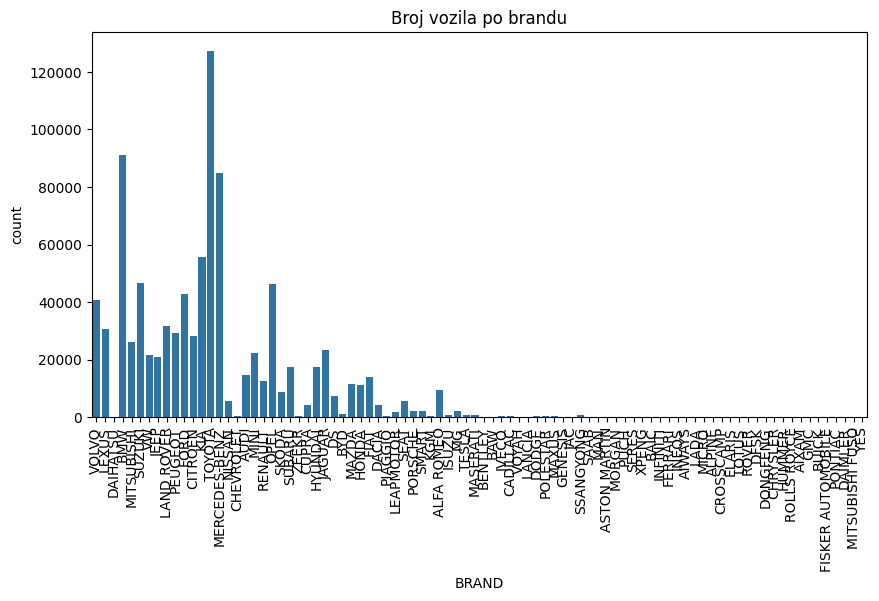

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x="BRAND", data=df_merged)
plt.xticks(rotation=90)
plt.title("Broj vozila po brandu")
plt.show()

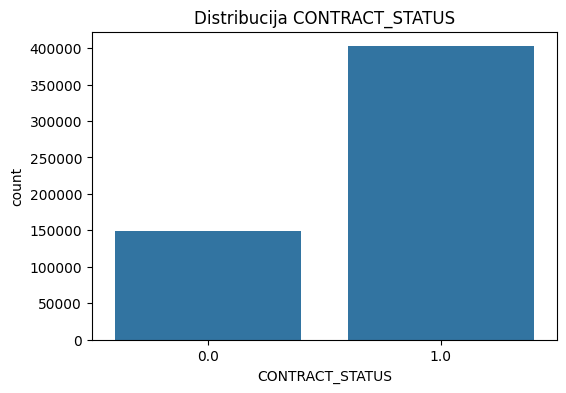

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="CONTRACT_STATUS", data=df_merged)
plt.title("Distribucija CONTRACT_STATUS")
plt.show()

In [ ]:
df_merged.duplicated().sum()

np.int64(0)

In [ ]:
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

CONTRACT_LAST_MODIFIED               380596
CONTRACT_STATUS                      380596
CONTRACT_MODIFICATION_DURATION       380596
CONTRACT_DATE_CREATED_IS_WEEKEND     380596
CONTRACT_LAST_MODIFIED_IS_WEEKEND    380596
OFFER_LAST_MODIFIED                  629893
OFFER_STATUS                         629893
OFFER_DURATION                       629893
OFFER_DATE_CREATED_IS_WEEKEND        629893
OFFER_LAST_MODIFIED_IS_WEEKEND       629893
LEAD_STATUS                          915126
LEAD_CLOSING_DATE                    915126
LEAD_DURATION                        915126
LEAD_DATE_CREATED_IS_WEEKEND         915126
LEAD_CLOSING_DATE_IS_WEEKEND         915126
dtype: int64


In [ ]:
nan_columns_to_fill_with_0 = [
    'CONTRACT_MODIFICATION_DURATION',
    'CONTRACT_DATE_CREATED_IS_WEEKEND',
    'CONTRACT_LAST_MODIFIED_IS_WEEKEND',
    'OFFER_DURATION',
    'OFFER_DATE_CREATED_IS_WEEKEND',
    'OFFER_LAST_MODIFIED_IS_WEEKEND',
    'LEAD_DURATION',
    'LEAD_DATE_CREATED_IS_WEEKEND',
    'LEAD_CLOSING_DATE_IS_WEEKEND'
]

for col in nan_columns_to_fill_with_0:
    df_merged[col] = df_merged[col].fillna(0)

print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

CONTRACT_LAST_MODIFIED    380596
CONTRACT_STATUS           380596
OFFER_LAST_MODIFIED       629893
OFFER_STATUS              629893
LEAD_STATUS               915126
LEAD_CLOSING_DATE         915126
dtype: int64


In [ ]:
df_merged.to_csv('df_najnoviji.csv', index=False)

# Kodiranje

In [ ]:
one_hot = [
    'PUBLISH_STATUS',
    'TRANSMISSION',
    'DRIVE_TYPE',
    'FUEL_TYPE',
    'OFFER_STATUS',
    'LEAD_STATUS',
    'MARKETPLACE'
]

df_merged = pd.get_dummies(df_merged, columns=one_hot, dummy_na=True)

In [ ]:
frequency_encoding = ['BRAND', 'MODEL', 'MODEL_VERSION']

for col in frequency_encoding:
    freq = df_merged[col].value_counts(normalize=True)
    df_merged[col + '_FREQ'] = df_merged[col].map(freq)

df_merged.drop(columns=frequency_encoding, inplace=True)

In [ ]:
freq = df_merged['BODY_TYPE'].value_counts(normalize=True)
df_merged['BODY_TYPE_FREQ'] = df_merged['BODY_TYPE'].map(freq)
df_merged.drop('BODY_TYPE', axis=1, inplace=True)

In [ ]:
df_merged.describe()

,DATE_START,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS,DURATION,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,...,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND,LEAD_CLOSING_DATE,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND,BRAND_FREQ,MODEL_FREQ,MODEL_VERSION_FREQ,BODY_TYPE_FREQ
count,932256,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000,...,932256.000000,932256.000000,17130,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000,932256.000000
mean,2024-08-29 03:20:32.097227776,113.197701,2022.030529,24138.510358,40441.545862,30.926025,30.926025,0.076025,0.372556,2.969471,...,0.047118,0.045048,2024-11-07 23:25:50.122340096,0.451084,0.005420,0.001485,0.058327,0.006643,0.000694,0.369080
min,2023-02-01 10:48:42.607000,0.000000,1985.000000,1.000000,1200.000000,30.000000,30.000000,0.000000,0.000000,-0.646809,...,0.000000,0.000000,2023-06-05 09:35:36.527000,0.000000,0.000000,0.000000,0.000001,0.000001,0.000001,0.000054
25%,2023-11-24 17:38:37.400000,38.000000,2021.000000,150.000000,27900.000000,31.000000,31.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,2024-03-05 16:11:48.751000064,0.000000,0.000000,0.000000,0.025092,0.002223,0.000053,0.265835
50%,2024-08-29 08:03:03.716999936,131.000000,2023.000000,11200.000000,37900.000000,31.000000,31.000000,0.000000,0.000000,2.000000,...,0.000000,0.000000,2024-09-30 18:23:03.385999872,0.000000,0.000000,0.000000,0.045938,0.005027,0.000264,0.535486
75%,2025-06-10 17:12:29.306000128,162.685804,2024.000000,36000.000000,51700.000000,31.000000,31.000000,0.000000,1.000000,4.000000,...,0.000000,0.000000,2025-07-15 11:01:55,0.000000,0.000000,0.000000,0.091129,0.009386,0.000930,0.535486
max,2026-02-28 18:28:24.827000,919.000000,2025.646809,400000.000000,80000.000000,31.000000,31.000000,1.000000,1.000000,40.000000,...,1.000000,1.000000,2026-03-03 08:26:56.980000,733.000000,1.000000,1.000000,0.136678,0.024587,0.007972,0.535486
std,NaN,74.775480,2.656362,31303.148781,16424.266717,0.261731,0.261731,0.265039,0.483486,2.656362,...,0.211891,0.207409,NaN,9.821896,0.073422,0.038502,0.041477,0.005568,0.001084,0.192385


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 932256 entries, 0 to 932405
Data columns (total 65 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   DATE_START                         932256 non-null  datetime64[ns]
 1   CO2_EMISSION                       932256 non-null  float64       
 2   PRODUCTION_YEAR                    932256 non-null  float64       
 3   CURRENT_MILEAGE                    932256 non-null  float64       
 4   PRICE                              932256 non-null  float64       
 5   DURATION_DAYS                      932256 non-null  int64         
 6   DURATION                           932256 non-null  int64         
 7   DATE_START_IS_WEEKEND              932256 non-null  int64         
 8   DATE_END_IS_WEEKEND                932256 non-null  int64         
 9   AGE                                932256 non-null  float64       
 10  CONTRACT_LAST_MODIFIED   

In [ ]:
df_merged[df_merged.duplicated()].head()

,DATE_START,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS,DURATION,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,...,LEAD_STATUS_nan,MARKETPLACE_AutoMarket,MARKETPLACE_AutoTradeNet,MARKETPLACE_CarFinder,MARKETPLACE_VehicleHub,MARKETPLACE_nan,BRAND_FREQ,MODEL_FREQ,MODEL_VERSION_FREQ,BODY_TYPE_FREQ
21434,2025-11-12 11:28:01.513,0.0,2025.0,20.0,34950.0,31,31,0,1,0.0,...,True,False,True,False,False,False,0.059598,0.002134,0.000004,0.535486
33022,2023-04-17 15:48:46.160,197.0,2017.0,67400.0,43800.0,31,31,0,0,8.0,...,True,False,True,False,False,False,0.097683,0.007146,0.000002,0.535486
41411,2024-04-22 15:49:10.987,45.0,2021.0,55600.0,36900.0,31,31,0,0,4.0,...,True,False,True,False,False,False,0.043636,0.010291,0.000002,0.535486
47487,2025-08-04 17:18:30.160,0.0,2025.0,50.0,53980.0,31,31,0,0,0.0,...,True,False,False,False,True,False,0.000947,0.000177,0.000001,0.535486
50684,2025-01-25 13:16:00.313,36.0,2023.0,8500.0,41940.0,31,31,1,0,2.0,...,True,False,False,False,True,False,0.007817,0.003437,0.000002,0.535486


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 932256 entries, 0 to 932405
Data columns (total 65 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   DATE_START                         932256 non-null  datetime64[ns]
 1   CO2_EMISSION                       932256 non-null  float64       
 2   PRODUCTION_YEAR                    932256 non-null  float64       
 3   CURRENT_MILEAGE                    932256 non-null  float64       
 4   PRICE                              932256 non-null  float64       
 5   DURATION_DAYS                      932256 non-null  int64         
 6   DURATION                           932256 non-null  int64         
 7   DATE_START_IS_WEEKEND              932256 non-null  int64         
 8   DATE_END_IS_WEEKEND                932256 non-null  int64         
 9   AGE                                932256 non-null  float64       
 10  CONTRACT_LAST_MODIFIED   

In [ ]:
df_merged.duplicated().sum()

np.int64(2193)

In [ ]:
df_merged = df_merged.drop_duplicates()

In [ ]:
df_merged = df_merged.drop("CONTRACT_LAST_MODIFIED", axis=1)
df_merged = df_merged.drop("OFFER_LAST_MODIFIED", axis=1)
df_merged = df_merged.drop("LEAD_CLOSING_DATE", axis=1)

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 930063 entries, 0 to 932405
Data columns (total 62 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   DATE_START                         930063 non-null  datetime64[ns]
 1   CO2_EMISSION                       930063 non-null  float64       
 2   PRODUCTION_YEAR                    930063 non-null  float64       
 3   CURRENT_MILEAGE                    930063 non-null  float64       
 4   PRICE                              930063 non-null  float64       
 5   DURATION_DAYS                      930063 non-null  int64         
 6   DURATION                           930063 non-null  int64         
 7   DATE_START_IS_WEEKEND              930063 non-null  int64         
 8   DATE_END_IS_WEEKEND                930063 non-null  int64         
 9   AGE                                930063 non-null  float64       
 10  CONTRACT_STATUS          

In [ ]:
df_merged.duplicated().sum()

np.int64(13690)

In [ ]:
df_merged = df_merged.drop_duplicates()

In [ ]:
df_merged.duplicated().sum()

np.int64(0)

# Dodatno čišćenje za model

In [ ]:
df_merged.head()

,DATE_START,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS,DURATION,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,...,LEAD_STATUS_nan,MARKETPLACE_AutoMarket,MARKETPLACE_AutoTradeNet,MARKETPLACE_CarFinder,MARKETPLACE_VehicleHub,MARKETPLACE_nan,BRAND_FREQ,MODEL_FREQ,MODEL_VERSION_FREQ,BODY_TYPE_FREQ
0,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,31,31,0,0,2.0,...,True,False,True,False,False,False,0.043636,0.005437,0.000006,0.265835
1,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,31,31,0,0,2.0,...,True,False,True,False,False,False,0.043636,0.005437,0.000002,0.265835
2,2024-06-20 17:19:10.857,25.0,2023.0,35000.0,71900.0,31,31,0,1,2.0,...,True,False,False,False,True,False,0.032879,0.006254,0.000186,0.535486
3,2025-08-08 14:11:41.137,172.0,2009.0,215000.0,4200.0,31,31,0,0,16.0,...,True,True,False,False,False,False,0.000086,0.000005,0.000005,0.026191
4,2024-06-18 17:19:42.637,0.0,2023.0,13400.0,50900.0,31,31,0,0,2.0,...,True,False,False,False,True,False,0.097683,0.010781,0.000034,0.091711


In [ ]:
df_merged['CONTRACT_STATUS'] = df_merged['CONTRACT_STATUS'].fillna(0)

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 916373 entries, 0 to 932405
Data columns (total 62 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   DATE_START                         916373 non-null  datetime64[ns]
 1   CO2_EMISSION                       916373 non-null  float64       
 2   PRODUCTION_YEAR                    916373 non-null  float64       
 3   CURRENT_MILEAGE                    916373 non-null  float64       
 4   PRICE                              916373 non-null  float64       
 5   DURATION_DAYS                      916373 non-null  int64         
 6   DURATION                           916373 non-null  int64         
 7   DATE_START_IS_WEEKEND              916373 non-null  int64         
 8   DATE_END_IS_WEEKEND                916373 non-null  int64         
 9   AGE                                916373 non-null  float64       
 10  CONTRACT_STATUS          

In [ ]:
display(df_merged['MARKETPLACE_nan'].sum())

np.int64(0)

In [ ]:
df_merged = df_merged.drop(columns=['MARKETPLACE_nan'])

In [ ]:
# Provjeri sve _nan kolone odjednom
nan_cols = [col for col in df_merged.columns if col.endswith('_nan')]
display(df_merged[nan_cols].sum())

,0
PUBLISH_STATUS_nan,0
TRANSMISSION_nan,0
DRIVE_TYPE_nan,0
FUEL_TYPE_nan,0
OFFER_STATUS_nan,617606
LEAD_STATUS_nan,900612


In [ ]:
# Makni sve _nan kolone koje su sve 0 (beskorisne)
cols_to_drop = ['PUBLISH_STATUS_nan',
                'TRANSMISSION_nan', 'DRIVE_TYPE_nan', 'FUEL_TYPE_nan']

df_merged = df_merged.drop(columns=cols_to_drop)

In [ ]:
print(df_merged['CONTRACT_STATUS'].value_counts())
print("---")
print(df_merged['CONTRACT_STATUS'].value_counts(normalize=True).round(2))

CONTRACT_STATUS
0.0    515674
1.0    400699
Name: count, dtype: int64
---
CONTRACT_STATUS
0.0    0.56
1.0    0.44
Name: proportion, dtype: float64


In [ ]:
print((df_merged['DURATION_DAYS'] == df_merged['DURATION']).all())

True


In [ ]:
pd.set_option('display.max_columns', None)
df_merged.head()

,DATE_START,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS,DURATION,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,CONTRACT_STATUS,CONTRACT_MODIFICATION_DURATION,CONTRACT_DATE_CREATED_IS_WEEKEND,CONTRACT_LAST_MODIFIED_IS_WEEKEND,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND,PUBLISH_STATUS_Active,PUBLISH_STATUS_Deactivated,PUBLISH_STATUS_Unpublished,TRANSMISSION_Automatic,TRANSMISSION_CVT,TRANSMISSION_Manual,TRANSMISSION_Other,TRANSMISSION_Semi-Automatic,DRIVE_TYPE_AWD,DRIVE_TYPE_FWD,DRIVE_TYPE_RWD,DRIVE_TYPE_UNKNOWN,FUEL_TYPE_Diesel,FUEL_TYPE_Electric,FUEL_TYPE_Gas,FUEL_TYPE_Hybrid,FUEL_TYPE_Mild Hybrid,FUEL_TYPE_Other,FUEL_TYPE_Petrol,FUEL_TYPE_Plug-in Hybrid,OFFER_STATUS_canceled,OFFER_STATUS_completed,OFFER_STATUS_nan,LEAD_STATUS_allocated,LEAD_STATUS_contacted,LEAD_STATUS_disqualified,LEAD_STATUS_follow_up,LEAD_STATUS_pool,LEAD_STATUS_nan,MARKETPLACE_AutoMarket,MARKETPLACE_AutoTradeNet,MARKETPLACE_CarFinder,MARKETPLACE_VehicleHub,BRAND_FREQ,MODEL_FREQ,MODEL_VERSION_FREQ,BODY_TYPE_FREQ
0,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,31,31,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000006,0.265835
1,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,31,31,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000002,0.265835
2,2024-06-20 17:19:10.857,25.0,2023.0,35000.0,71900.0,31,31,0,1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,0.032879,0.006254,0.000186,0.535486
3,2025-08-08 14:11:41.137,172.0,2009.0,215000.0,4200.0,31,31,0,0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False,0.000086,0.000005,0.000005,0.026191
4,2024-06-18 17:19:42.637,0.0,2023.0,13400.0,50900.0,31,31,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,0.097683,0.010781,0.000034,0.091711


In [ ]:
df_merged = df_merged.drop(columns=['DURATION', 'DURATION_DAYS'])

In [ ]:
pd.set_option('display.max_columns', None)
df_merged.head()

,DATE_START,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,CONTRACT_STATUS,CONTRACT_MODIFICATION_DURATION,CONTRACT_DATE_CREATED_IS_WEEKEND,CONTRACT_LAST_MODIFIED_IS_WEEKEND,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND,PUBLISH_STATUS_Active,PUBLISH_STATUS_Deactivated,PUBLISH_STATUS_Unpublished,TRANSMISSION_Automatic,TRANSMISSION_CVT,TRANSMISSION_Manual,TRANSMISSION_Other,TRANSMISSION_Semi-Automatic,DRIVE_TYPE_AWD,DRIVE_TYPE_FWD,DRIVE_TYPE_RWD,DRIVE_TYPE_UNKNOWN,FUEL_TYPE_Diesel,FUEL_TYPE_Electric,FUEL_TYPE_Gas,FUEL_TYPE_Hybrid,FUEL_TYPE_Mild Hybrid,FUEL_TYPE_Other,FUEL_TYPE_Petrol,FUEL_TYPE_Plug-in Hybrid,OFFER_STATUS_canceled,OFFER_STATUS_completed,OFFER_STATUS_nan,LEAD_STATUS_allocated,LEAD_STATUS_contacted,LEAD_STATUS_disqualified,LEAD_STATUS_follow_up,LEAD_STATUS_pool,LEAD_STATUS_nan,MARKETPLACE_AutoMarket,MARKETPLACE_AutoTradeNet,MARKETPLACE_CarFinder,MARKETPLACE_VehicleHub,BRAND_FREQ,MODEL_FREQ,MODEL_VERSION_FREQ,BODY_TYPE_FREQ
0,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000006,0.265835
1,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000002,0.265835
2,2024-06-20 17:19:10.857,25.0,2023.0,35000.0,71900.0,0,1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,0.032879,0.006254,0.000186,0.535486
3,2025-08-08 14:11:41.137,172.0,2009.0,215000.0,4200.0,0,0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False,0.000086,0.000005,0.000005,0.026191
4,2024-06-18 17:19:42.637,0.0,2023.0,13400.0,50900.0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,0.097683,0.010781,0.000034,0.091711


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 916373 entries, 0 to 932405
Data columns (total 55 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   DATE_START                         916373 non-null  datetime64[ns]
 1   CO2_EMISSION                       916373 non-null  float64       
 2   PRODUCTION_YEAR                    916373 non-null  float64       
 3   CURRENT_MILEAGE                    916373 non-null  float64       
 4   PRICE                              916373 non-null  float64       
 5   DATE_START_IS_WEEKEND              916373 non-null  int64         
 6   DATE_END_IS_WEEKEND                916373 non-null  int64         
 7   AGE                                916373 non-null  float64       
 8   CONTRACT_STATUS                    916373 non-null  float64       
 9   CONTRACT_MODIFICATION_DURATION     916373 non-null  float64       
 10  CONTRACT_DATE_CREATED_IS_

In [ ]:
print(f"Duplikati: {df_merged.duplicated().sum()}")

Duplikati: 0


In [ ]:
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Series([], dtype: int64)


In [ ]:
print(df_merged[['CO2_EMISSION','CURRENT_MILEAGE','PRICE','AGE']].describe())

        CO2_EMISSION  CURRENT_MILEAGE          PRICE            AGE
count  916373.000000    916373.000000  916373.000000  916373.000000
mean      112.989974     24250.352198   40352.800519       2.970927
std        74.696673     31408.439404   16385.108057       2.666587
min         0.000000         1.000000    1200.000000      -0.646809
25%        38.000000       150.000000   27900.000000       1.000000
50%       130.000000     11333.000000   37900.000000       2.000000
75%       162.685804     36232.000000   51480.000000       4.000000
max       919.000000    400000.000000   80000.000000      40.000000


In [ ]:
df_merged['AGE'].min()

-0.6468085106382659

In [ ]:
df_merged = df_merged[df_merged['AGE'] >= 0]

In [ ]:
print(df_merged['CONTRACT_STATUS'].unique())
print(df_merged['CONTRACT_STATUS'].value_counts())

[1. 0.]
CONTRACT_STATUS
0.0    512304
1.0    400699
Name: count, dtype: int64


In [ ]:
print(df_merged[['BRAND_FREQ','MODEL_FREQ','MODEL_VERSION_FREQ','BODY_TYPE_FREQ']].corr())

                    BRAND_FREQ  MODEL_FREQ  MODEL_VERSION_FREQ  BODY_TYPE_FREQ
BRAND_FREQ            1.000000    0.505623            0.341250       -0.050104
MODEL_FREQ            0.505623    1.000000            0.479672        0.104999
MODEL_VERSION_FREQ    0.341250    0.479672            1.000000        0.105315
BODY_TYPE_FREQ       -0.050104    0.104999            0.105315        1.000000


In [ ]:
df_merged = df_merged.drop_duplicates()

In [ ]:
df_merged.head()

,DATE_START,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,CONTRACT_STATUS,CONTRACT_MODIFICATION_DURATION,CONTRACT_DATE_CREATED_IS_WEEKEND,CONTRACT_LAST_MODIFIED_IS_WEEKEND,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND,PUBLISH_STATUS_Active,PUBLISH_STATUS_Deactivated,PUBLISH_STATUS_Unpublished,TRANSMISSION_Automatic,TRANSMISSION_CVT,TRANSMISSION_Manual,TRANSMISSION_Other,TRANSMISSION_Semi-Automatic,DRIVE_TYPE_AWD,DRIVE_TYPE_FWD,DRIVE_TYPE_RWD,DRIVE_TYPE_UNKNOWN,FUEL_TYPE_Diesel,FUEL_TYPE_Electric,FUEL_TYPE_Gas,FUEL_TYPE_Hybrid,FUEL_TYPE_Mild Hybrid,FUEL_TYPE_Other,FUEL_TYPE_Petrol,FUEL_TYPE_Plug-in Hybrid,OFFER_STATUS_canceled,OFFER_STATUS_completed,OFFER_STATUS_nan,LEAD_STATUS_allocated,LEAD_STATUS_contacted,LEAD_STATUS_disqualified,LEAD_STATUS_follow_up,LEAD_STATUS_pool,LEAD_STATUS_nan,MARKETPLACE_AutoMarket,MARKETPLACE_AutoTradeNet,MARKETPLACE_CarFinder,MARKETPLACE_VehicleHub,BRAND_FREQ,MODEL_FREQ,MODEL_VERSION_FREQ,BODY_TYPE_FREQ
0,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000006,0.265835
1,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000002,0.265835
2,2024-06-20 17:19:10.857,25.0,2023.0,35000.0,71900.0,0,1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,0.032879,0.006254,0.000186,0.535486
3,2025-08-08 14:11:41.137,172.0,2009.0,215000.0,4200.0,0,0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False,0.000086,0.000005,0.000005,0.026191
4,2024-06-18 17:19:42.637,0.0,2023.0,13400.0,50900.0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,0.097683,0.010781,0.000034,0.091711


In [ ]:
print(df_merged.isnull().sum()[df_merged.isnull().sum() > 0])

Series([], dtype: int64)


In [ ]:
nan_columns = [
    'CONTRACT_MODIFICATION_DURATION',
    'CONTRACT_DATE_CREATED_IS_WEEKEND',
    'CONTRACT_LAST_MODIFIED_IS_WEEKEND',
    'OFFER_DURATION',
    'OFFER_DATE_CREATED_IS_WEEKEND',
    'OFFER_LAST_MODIFIED_IS_WEEKEND',
    'LEAD_DURATION',
    'LEAD_DATE_CREATED_IS_WEEKEND',
    'LEAD_CLOSING_DATE_IS_WEEKEND'
]

for col in nan_columns:
    print(f"Value counts for {col}:")
    print(df_merged[col].value_counts(dropna=False))
    print("---") #MOZDA MAKNIT POSLIJE

Value counts for CONTRACT_MODIFICATION_DURATION:
CONTRACT_MODIFICATION_DURATION
0.0      484978
6.0       27825
7.0       24269
1.0       22991
3.0       22089
          ...  
502.0         2
235.0         1
607.0         1
436.0         1
710.0         1
Name: count, Length: 533, dtype: int64
---
Value counts for CONTRACT_DATE_CREATED_IS_WEEKEND:
CONTRACT_DATE_CREATED_IS_WEEKEND
0.0    850026
1.0     62977
Name: count, dtype: int64
---
Value counts for CONTRACT_LAST_MODIFIED_IS_WEEKEND:
CONTRACT_LAST_MODIFIED_IS_WEEKEND
0.0    896208
1.0     16795
Name: count, dtype: int64
---
Value counts for OFFER_DURATION:
OFFER_DURATION
0.0      855142
1.0       19117
2.0       14650
3.0        9273
4.0        5339
          ...  
416.0         2
143.0         2
313.0         2
486.0         2
248.0         2
Name: count, Length: 161, dtype: int64
---
Value counts for OFFER_DATE_CREATED_IS_WEEKEND:
OFFER_DATE_CREATED_IS_WEEKEND
0.0    869343
1.0     43660
Name: count, dtype: int64
---
Value counts

In [ ]:
df_merged['MONTH'] = pd.to_datetime(df_merged['DATE_START']).dt.month

df_merged['SEASON'] = df_merged['MONTH'].map({
    12: 'Zima', 1: 'Zima', 2: 'Zima',
    3: 'Proljeće', 4: 'Proljeće', 5: 'Proljeće',
    6: 'Ljeto', 7: 'Ljeto', 8: 'Ljeto',
    9: 'Jesen', 10: 'Jesen', 11: 'Jesen'
})

print(df_merged['MONTH'].value_counts().sort_index())
print(df_merged['SEASON'].value_counts())

MONTH
1      75516
2      80043
3      70288
4      63781
5      67350
6     126971
7      82319
8      70131
9      73198
10     68995
11     64613
12     69798
Name: count, dtype: int64
SEASON
Ljeto       279421
Zima        225357
Jesen       206806
Proljeće    201419
Name: count, dtype: int64


In [ ]:
df_merged.head()

,DATE_START,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,CONTRACT_STATUS,CONTRACT_MODIFICATION_DURATION,CONTRACT_DATE_CREATED_IS_WEEKEND,CONTRACT_LAST_MODIFIED_IS_WEEKEND,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND,PUBLISH_STATUS_Active,PUBLISH_STATUS_Deactivated,PUBLISH_STATUS_Unpublished,TRANSMISSION_Automatic,TRANSMISSION_CVT,TRANSMISSION_Manual,TRANSMISSION_Other,TRANSMISSION_Semi-Automatic,DRIVE_TYPE_AWD,DRIVE_TYPE_FWD,DRIVE_TYPE_RWD,DRIVE_TYPE_UNKNOWN,FUEL_TYPE_Diesel,FUEL_TYPE_Electric,FUEL_TYPE_Gas,FUEL_TYPE_Hybrid,FUEL_TYPE_Mild Hybrid,FUEL_TYPE_Other,FUEL_TYPE_Petrol,FUEL_TYPE_Plug-in Hybrid,OFFER_STATUS_canceled,OFFER_STATUS_completed,OFFER_STATUS_nan,LEAD_STATUS_allocated,LEAD_STATUS_contacted,LEAD_STATUS_disqualified,LEAD_STATUS_follow_up,LEAD_STATUS_pool,LEAD_STATUS_nan,MARKETPLACE_AutoMarket,MARKETPLACE_AutoTradeNet,MARKETPLACE_CarFinder,MARKETPLACE_VehicleHub,BRAND_FREQ,MODEL_FREQ,MODEL_VERSION_FREQ,BODY_TYPE_FREQ,MONTH,SEASON
0,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000006,0.265835,4,Proljeće
1,2024-04-05 10:01:23.327,0.0,2023.0,8800.0,38500.0,0,0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0.043636,0.005437,0.000002,0.265835,4,Proljeće
2,2024-06-20 17:19:10.857,25.0,2023.0,35000.0,71900.0,0,1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,0.032879,0.006254,0.000186,0.535486,6,Ljeto
3,2025-08-08 14:11:41.137,172.0,2009.0,215000.0,4200.0,0,0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False,0.000086,0.000005,0.000005,0.026191,8,Ljeto
4,2024-06-18 17:19:42.637,0.0,2023.0,13400.0,50900.0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,True,False,False,False,False,True,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,0.097683,0.010781,0.000034,0.091711,6,Ljeto


In [ ]:
df_merged.duplicated().sum()

np.int64(0)

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 913003 entries, 0 to 932405
Data columns (total 57 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   DATE_START                         913003 non-null  datetime64[ns]
 1   CO2_EMISSION                       913003 non-null  float64       
 2   PRODUCTION_YEAR                    913003 non-null  float64       
 3   CURRENT_MILEAGE                    913003 non-null  float64       
 4   PRICE                              913003 non-null  float64       
 5   DATE_START_IS_WEEKEND              913003 non-null  int64         
 6   DATE_END_IS_WEEKEND                913003 non-null  int64         
 7   AGE                                913003 non-null  float64       
 8   CONTRACT_STATUS                    913003 non-null  float64       
 9   CONTRACT_MODIFICATION_DURATION     913003 non-null  float64       
 10  CONTRACT_DATE_CREATED_IS_

In [ ]:
df_merged.isna().sum()

,0
DATE_START,0
CO2_EMISSION,0
PRODUCTION_YEAR,0
CURRENT_MILEAGE,0
PRICE,0
DATE_START_IS_WEEKEND,0
DATE_END_IS_WEEKEND,0
AGE,0
CONTRACT_STATUS,0
CONTRACT_MODIFICATION_DURATION,0


In [ ]:
nan_columns_to_fill_with_0 = [
    'CONTRACT_MODIFICATION_DURATION',
    'CONTRACT_DATE_CREATED_IS_WEEKEND',
    'CONTRACT_LAST_MODIFIED_IS_WEEKEND',
    'OFFER_DURATION',
    'OFFER_DATE_CREATED_IS_WEEKEND',
    'OFFER_LAST_MODIFIED_IS_WEEKEND',
    'LEAD_DURATION',
    'LEAD_DATE_CREATED_IS_WEEKEND',
    'LEAD_CLOSING_DATE_IS_WEEKEND'
]

for col in nan_columns_to_fill_with_0:
    df_merged[col] = df_merged[col].fillna(0)


In [ ]:
df_merged.duplicated().sum()

np.int64(0)

In [ ]:
df_merged.isna().sum()

,0
DATE_START,0
CO2_EMISSION,0
PRODUCTION_YEAR,0
CURRENT_MILEAGE,0
PRICE,0
DATE_START_IS_WEEKEND,0
DATE_END_IS_WEEKEND,0
AGE,0
CONTRACT_STATUS,0
CONTRACT_MODIFICATION_DURATION,0


In [ ]:
df_merged.shape

(913003, 57)

In [ ]:
df_merged.duplicated().sum()

np.int64(0)

In [ ]:
df_merged.to_csv('df_segmentation.csv', index=False)

In [ ]:
df_segmentation = pd.read_csv('df_segmentation.csv')

In [ ]:
# Makni AutoMarket
df_segmentation = df_segmentation.drop(columns=['MARKETPLACE_AutoMarket'])

# Spremi nazad
df_segmentation.to_csv('df_segmentation.csv', index=False)

print(df_segmentation.shape)
print(df_segmentation.columns.tolist())

(913003, 56)
['DATE_START', 'CO2_EMISSION', 'PRODUCTION_YEAR', 'CURRENT_MILEAGE', 'PRICE', 'DATE_START_IS_WEEKEND', 'DATE_END_IS_WEEKEND', 'AGE', 'CONTRACT_STATUS', 'CONTRACT_MODIFICATION_DURATION', 'CONTRACT_DATE_CREATED_IS_WEEKEND', 'CONTRACT_LAST_MODIFIED_IS_WEEKEND', 'OFFER_DURATION', 'OFFER_DATE_CREATED_IS_WEEKEND', 'OFFER_LAST_MODIFIED_IS_WEEKEND', 'LEAD_DURATION', 'LEAD_DATE_CREATED_IS_WEEKEND', 'LEAD_CLOSING_DATE_IS_WEEKEND', 'PUBLISH_STATUS_Active', 'PUBLISH_STATUS_Deactivated', 'PUBLISH_STATUS_Unpublished', 'TRANSMISSION_Automatic', 'TRANSMISSION_CVT', 'TRANSMISSION_Manual', 'TRANSMISSION_Other', 'TRANSMISSION_Semi-Automatic', 'DRIVE_TYPE_AWD', 'DRIVE_TYPE_FWD', 'DRIVE_TYPE_RWD', 'DRIVE_TYPE_UNKNOWN', 'FUEL_TYPE_Diesel', 'FUEL_TYPE_Electric', 'FUEL_TYPE_Gas', 'FUEL_TYPE_Hybrid', 'FUEL_TYPE_Mild Hybrid', 'FUEL_TYPE_Other', 'FUEL_TYPE_Petrol', 'FUEL_TYPE_Plug-in Hybrid', 'OFFER_STATUS_canceled', 'OFFER_STATUS_completed', 'OFFER_STATUS_nan', 'LEAD_STATUS_allocated', 'LEAD_STATUS

Ovaj zadnji se koristi u segmentaciji toj nekoj analizi, a za model cu napravit odvojen skup

# Model

In [ ]:
df_model_data = pd.read_csv('df_segmentation.csv')

In [ ]:
df_model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913003 entries, 0 to 913002
Data columns (total 56 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   DATE_START                         913003 non-null  object 
 1   CO2_EMISSION                       913003 non-null  float64
 2   PRODUCTION_YEAR                    913003 non-null  float64
 3   CURRENT_MILEAGE                    913003 non-null  float64
 4   PRICE                              913003 non-null  float64
 5   DATE_START_IS_WEEKEND              913003 non-null  int64  
 6   DATE_END_IS_WEEKEND                913003 non-null  int64  
 7   AGE                                913003 non-null  float64
 8   CONTRACT_STATUS                    913003 non-null  float64
 9   CONTRACT_MODIFICATION_DURATION     913003 non-null  float64
 10  CONTRACT_DATE_CREATED_IS_WEEKEND   913003 non-null  float64
 11  CONTRACT_LAST_MODIFIED_IS_WEEKEND  9130

In [ ]:
leakage_cols = [
    'DATE_END_IS_WEEKEND',
    'DATE_START',
    'CONTRACT_MODIFICATION_DURATION',
    'CONTRACT_DATE_CREATED_IS_WEEKEND',
    'CONTRACT_LAST_MODIFIED_IS_WEEKEND',
    'OFFER_DURATION',
    'OFFER_DATE_CREATED_IS_WEEKEND',
    'OFFER_LAST_MODIFIED_IS_WEEKEND',
    'LEAD_DURATION',
    'LEAD_DATE_CREATED_IS_WEEKEND',
    'LEAD_CLOSING_DATE_IS_WEEKEND',
    'OFFER_STATUS_canceled',
    'OFFER_STATUS_completed',
    'OFFER_STATUS_nan',
    'LEAD_STATUS_allocated',
    'LEAD_STATUS_contacted',
    'LEAD_STATUS_disqualified',
    'LEAD_STATUS_follow_up',
    'LEAD_STATUS_pool',
    'LEAD_STATUS_nan',
    'PUBLISH_STATUS_Active',
    'PUBLISH_STATUS_Deactivated',
    'PUBLISH_STATUS_Unpublished',
    'MONTH',
    'SEASON',
    'DATE_START_IS_WEEKEND',
    'PRODUCTION_YEAR'
]

df_model_data = df_model_data.drop(columns=leakage_cols)

# 3. Provjera
print(f"\nKolone u df_model_data:")
print(df_model_data.columns.tolist())


Kolone u df_model_data:
['CO2_EMISSION', 'CURRENT_MILEAGE', 'PRICE', 'AGE', 'CONTRACT_STATUS', 'TRANSMISSION_Automatic', 'TRANSMISSION_CVT', 'TRANSMISSION_Manual', 'TRANSMISSION_Other', 'TRANSMISSION_Semi-Automatic', 'DRIVE_TYPE_AWD', 'DRIVE_TYPE_FWD', 'DRIVE_TYPE_RWD', 'DRIVE_TYPE_UNKNOWN', 'FUEL_TYPE_Diesel', 'FUEL_TYPE_Electric', 'FUEL_TYPE_Gas', 'FUEL_TYPE_Hybrid', 'FUEL_TYPE_Mild Hybrid', 'FUEL_TYPE_Other', 'FUEL_TYPE_Petrol', 'FUEL_TYPE_Plug-in Hybrid', 'MARKETPLACE_AutoTradeNet', 'MARKETPLACE_CarFinder', 'MARKETPLACE_VehicleHub', 'BRAND_FREQ', 'MODEL_FREQ', 'MODEL_VERSION_FREQ', 'BODY_TYPE_FREQ']


In [ ]:
df_model_data.duplicated().sum()

np.int64(85501)

In [ ]:
df_model_data = df_model_data.drop_duplicates()
print(f"Nakon brisanja duplikata: {df_model_data.shape}")

Nakon brisanja duplikata: (827502, 29)


In [ ]:
df_model_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827502 entries, 0 to 913002
Data columns (total 29 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   CO2_EMISSION                 827502 non-null  float64
 1   CURRENT_MILEAGE              827502 non-null  float64
 2   PRICE                        827502 non-null  float64
 3   AGE                          827502 non-null  float64
 4   CONTRACT_STATUS              827502 non-null  float64
 5   TRANSMISSION_Automatic       827502 non-null  bool   
 6   TRANSMISSION_CVT             827502 non-null  bool   
 7   TRANSMISSION_Manual          827502 non-null  bool   
 8   TRANSMISSION_Other           827502 non-null  bool   
 9   TRANSMISSION_Semi-Automatic  827502 non-null  bool   
 10  DRIVE_TYPE_AWD               827502 non-null  bool   
 11  DRIVE_TYPE_FWD               827502 non-null  bool   
 12  DRIVE_TYPE_RWD               827502 non-null  bool   
 13  DRIV

In [ ]:
y = df_model_data['CONTRACT_STATUS']
X = df_model_data.drop(columns=['CONTRACT_STATUS'])

print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (827502, 28)
y: (827502,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\nOmjer u train skupu:")
print(y_train.value_counts(normalize=True).round(2))
print(f"\nOmjer u test skupu:")
print(y_test.value_counts(normalize=True).round(2))

X_train: (662001, 28)
X_test: (165501, 28)

Omjer u train skupu:
CONTRACT_STATUS
0.0    0.55
1.0    0.45
Name: proportion, dtype: float64

Omjer u test skupu:
CONTRACT_STATUS
0.0    0.55
1.0    0.45
Name: proportion, dtype: float64


Random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=50, n_estimators=50,
                       n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.75      0.72      0.74     90414
         1.0       0.68      0.72      0.70     75087

    accuracy                           0.72    165501
   macro avg       0.72      0.72      0.72    165501
weighted avg       0.72      0.72      0.72    165501


Confusion Matrix:
[[65541 24873]
 [21382 53705]]


XG Boost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.75      0.69      0.72     90414
         1.0       0.66      0.72      0.69     75087

    accuracy                           0.71    165501
   macro avg       0.70      0.71      0.70    165501
weighted avg       0.71      0.71      0.71    165501


Confusion Matrix:
[[62795 27619]
 [21112 53975]]


Testirane su dvije tehnike — Random Forest (50 stabala, max_depth=15) i XGBoost (100 stabala, max_depth=6). Random Forest je pokazao nešto bolje rezultate u precision i F1 metrici za klasu 1 (prodano), stoga je odabran kao finalni model.

Druga iteracija za forest

In [ ]:
rf_model_v4 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model_v4.fit(X_train, y_train)
y_pred_v4 = rf_model_v4.predict(X_test)
print(classification_report(y_test, y_pred_v4))

              precision    recall  f1-score   support

         0.0       0.76      0.76      0.76     90414
         1.0       0.71      0.72      0.72     75087

    accuracy                           0.74    165501
   macro avg       0.74      0.74      0.74    165501
weighted avg       0.74      0.74      0.74    165501



In [ ]:
print(confusion_matrix(y_test, y_pred_v4))

[[68467 21947]
 [21077 54010]]


In [ ]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, rf_model_v4.predict_proba(X_test)[:,1])
print(f'ROC-AUC: {roc:.4f}')

ROC-AUC: 0.8480


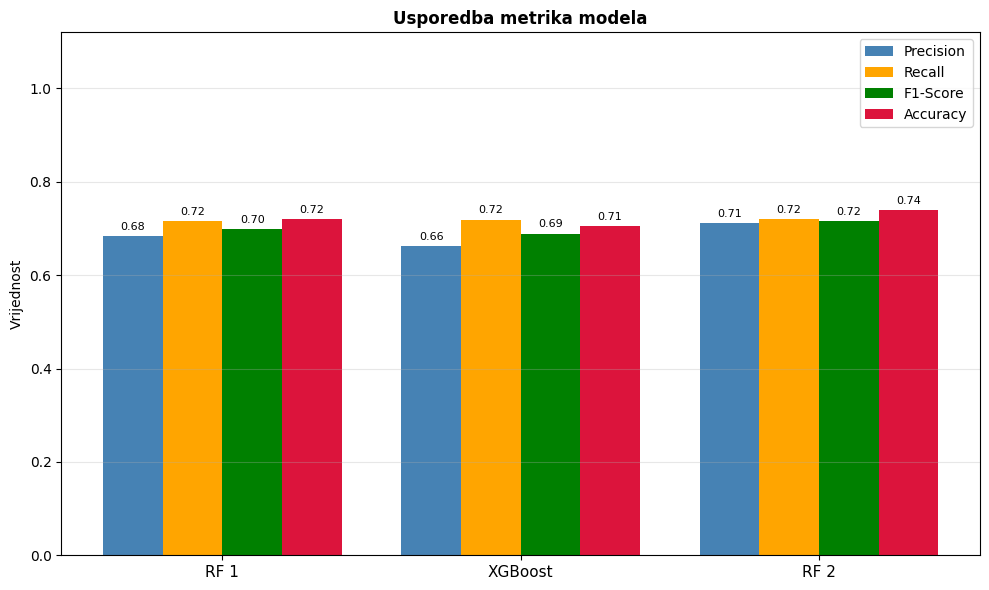

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

modeli = [
    (y_pred, 'RF 1'),
    (y_pred_xgb, 'XGBoost'),
    (y_pred_v4, 'RF 2'),
]

rezultati = []

for y_p, naziv in modeli:
    report = classification_report(y_test, y_p, output_dict=True)
    rezultati.append({
        'Model': naziv,
        'Precision': report['1.0']['precision'],
        'Recall': report['1.0']['recall'],
        'F1-Score': report['1.0']['f1-score'],
        'Accuracy': report['accuracy'],
    })

df = pd.DataFrame(rezultati).set_index('Model')

x = np.arange(len(df))
width = 0.2
metrike = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
boje = ['steelblue', 'orange', 'green', 'crimson']

fig, ax = plt.subplots(figsize=(10, 6))

for i, metrika in enumerate(metrike):
    bars = ax.bar(x + i * width, df[metrika], width, label=metrika, color=boje[i])
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df.index, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Vrijednost')
ax.set_title('Usporedba metrika modela', fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

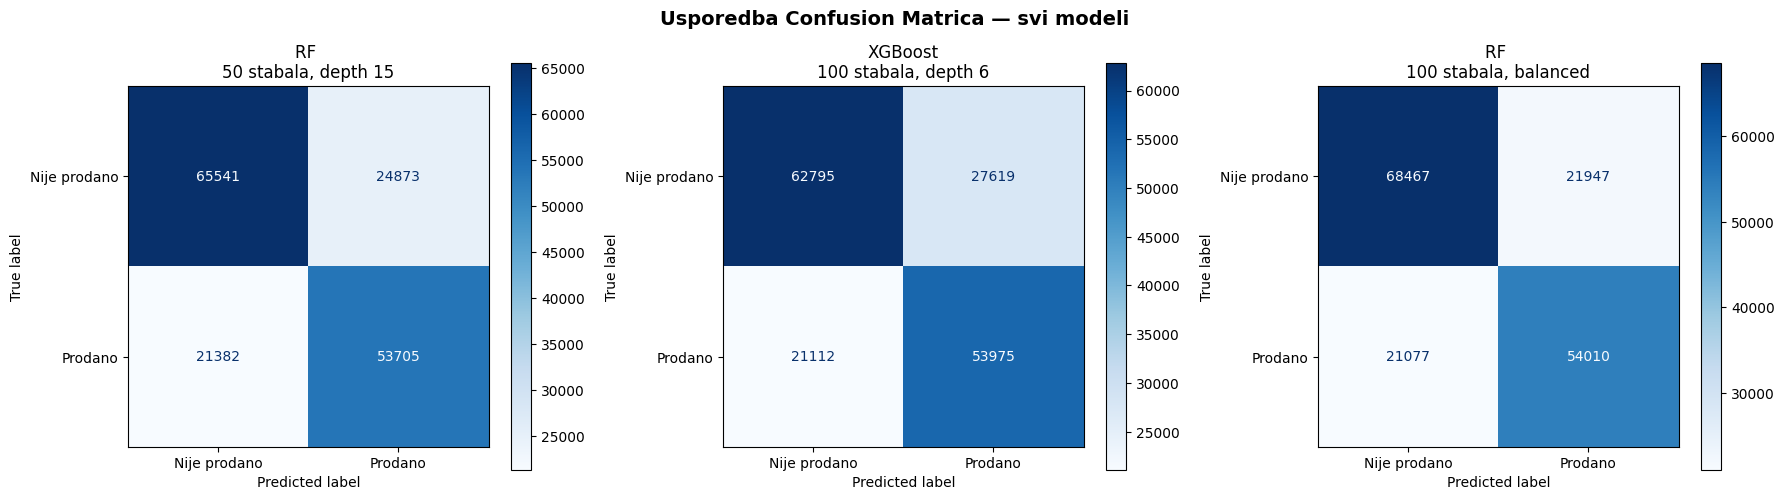

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modeli = [
    (y_pred, 'RF \n50 stabala, depth 15'),
    (y_pred_xgb, 'XGBoost\n100 stabala, depth 6'),
    (y_pred_v4, 'RF \n100 stabala, balanced'),
]

for i, (y_p, naziv) in enumerate(modeli):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_p,
        display_labels=['Nije prodano', 'Prodano'],
        cmap='Blues',
        ax=axes[i]
    )
    axes[i].set_title(naziv)

plt.suptitle('Usporedba Confusion Matrica — svi modeli', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Zadovoljni smo sa zadnjim modelom i idemo dalje sa analizom osjetljivosti

### Analiza osjetljivosti

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

features_df = pd.Series(
    rf_model_v4.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

features_pct = (features_df * 100).round(2)

print("Analiza osjetljivosti:")
for feature, importance in features_pct.items():
    print(f"{feature:<35} {importance:.2f}%")

Analiza osjetljivosti:
PRICE                               23.51%
CURRENT_MILEAGE                     21.55%
MODEL_VERSION_FREQ                  12.62%
AGE                                 7.80%
CO2_EMISSION                        7.62%
MODEL_FREQ                          6.05%
BRAND_FREQ                          5.39%
MARKETPLACE_AutoTradeNet            4.30%
BODY_TYPE_FREQ                      1.88%
MARKETPLACE_VehicleHub              1.84%
TRANSMISSION_CVT                    0.82%
FUEL_TYPE_Hybrid                    0.76%
MARKETPLACE_CarFinder               0.70%
TRANSMISSION_Automatic              0.65%
TRANSMISSION_Semi-Automatic         0.57%
DRIVE_TYPE_AWD                      0.54%
FUEL_TYPE_Mild Hybrid               0.53%
FUEL_TYPE_Petrol                    0.51%
DRIVE_TYPE_FWD                      0.50%
FUEL_TYPE_Plug-in Hybrid            0.45%
FUEL_TYPE_Diesel                    0.38%
TRANSMISSION_Manual                 0.32%
FUEL_TYPE_Electric                  0.27%
DRIVE_TY

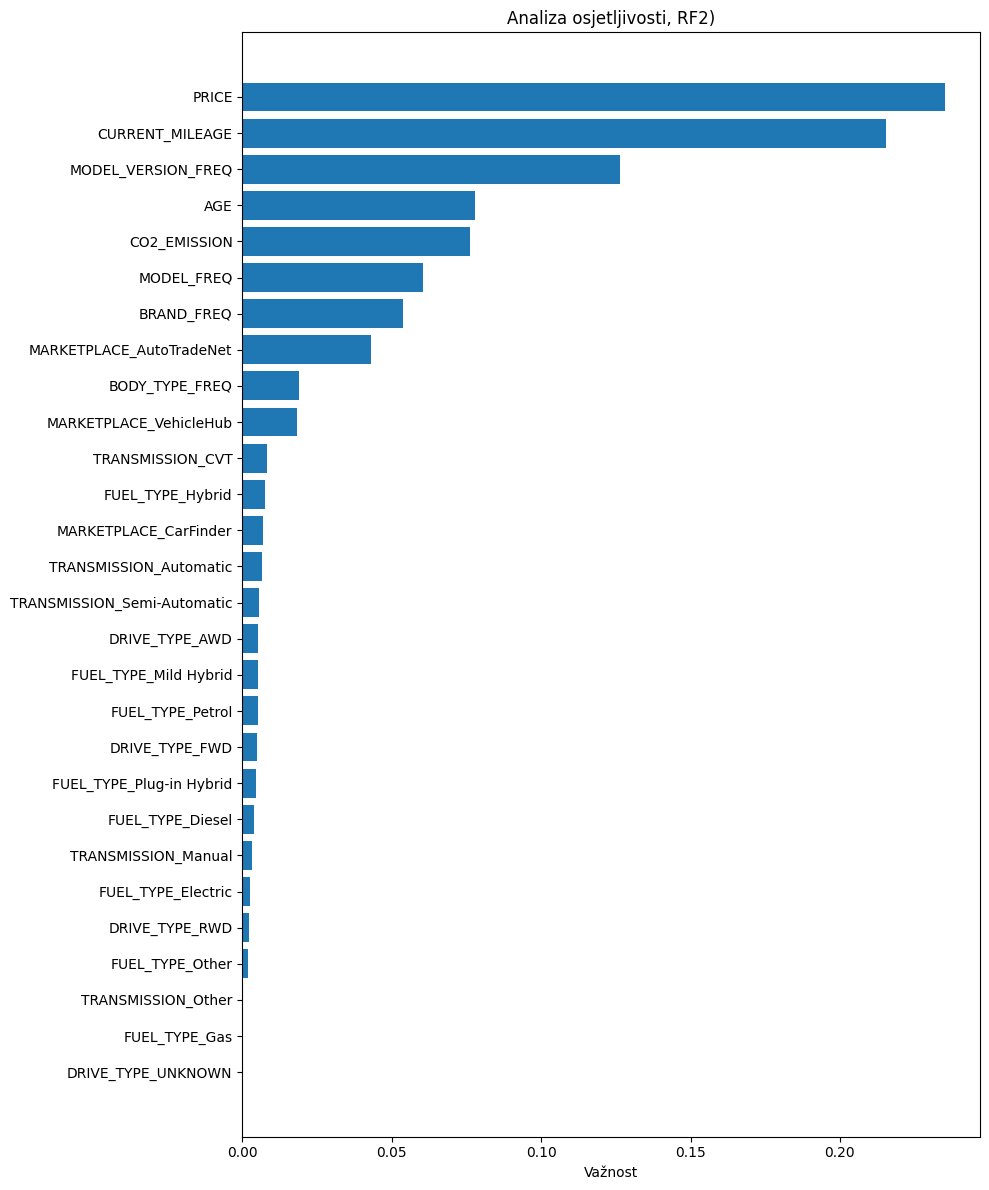

In [ ]:
plt.figure(figsize=(10, 12))
plt.barh(features_df.index[::-1], features_df.values[::-1])
plt.xlabel('Važnost')
plt.title('Analiza osjetljivosti, RF2)')
plt.tight_layout()
plt.show()

# Segmentacija tržišta

## 1.

In [ ]:
df = pd.read_csv('df_najnoviji.csv')
df = df[df['MARKETPLACE'] != 'AutoMarket']
df['DATE_START'] = pd.to_datetime(df['DATE_START'])
df['CONTRACT_LAST_MODIFIED'] = pd.to_datetime(df['CONTRACT_LAST_MODIFIED'])

In [ ]:
df.head()

,MARKETPLACE,PUBLISH_STATUS,DATE_START,BRAND,MODEL,MODEL_VERSION,BODY_TYPE,TRANSMISSION,DRIVE_TYPE,FUEL_TYPE,CO2_EMISSION,PRODUCTION_YEAR,CURRENT_MILEAGE,PRICE,DURATION_DAYS,DURATION,DATE_START_IS_WEEKEND,DATE_END_IS_WEEKEND,AGE,CONTRACT_LAST_MODIFIED,CONTRACT_STATUS,CONTRACT_MODIFICATION_DURATION,CONTRACT_DATE_CREATED_IS_WEEKEND,CONTRACT_LAST_MODIFIED_IS_WEEKEND,OFFER_LAST_MODIFIED,OFFER_STATUS,OFFER_DURATION,OFFER_DATE_CREATED_IS_WEEKEND,OFFER_LAST_MODIFIED_IS_WEEKEND,LEAD_STATUS,LEAD_CLOSING_DATE,LEAD_DURATION,LEAD_DATE_CREATED_IS_WEEKEND,LEAD_CLOSING_DATE_IS_WEEKEND
0,AutoTradeNet,Unpublished,2024-04-05 10:01:23.327,VOLVO,C40,C40 P8 Twin Recharge Ultimate AWD Jetzt von 0....,Sedan,Semi-Automatic,AWD,Electric,0.0,2023.0,8800.0,38500.0,31,31,0,0,2.0,2025-05-23 09:56:38.999,1.0,2.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
1,AutoTradeNet,Unpublished,2024-04-05 10:01:23.327,VOLVO,C40,C40 P8 Twin Recharge Ultimate AWD Approfittate...,Sedan,Semi-Automatic,AWD,Electric,0.0,2023.0,8800.0,38500.0,31,31,0,0,2.0,2025-05-23 09:56:38.999,1.0,2.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
2,VehicleHub,Unpublished,2024-06-20 17:19:10.857,LEXUS,NX,NX 450h+ F-Sport,SUV,CVT,AWD,Plug-in Hybrid,25.0,2023.0,35000.0,71900.0,31,31,0,1,2.0,NaT,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
4,VehicleHub,Unpublished,2024-06-18 17:19:42.637,BMW,3er,330e xDr Tour M Sport,Station Wagon,Semi-Automatic,AWD,Electric,0.0,2023.0,13400.0,50900.0,31,31,0,0,2.0,NaT,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
5,VehicleHub,Unpublished,2025-06-05 14:41:53.593,BMW,4er,xDrive Cabrio,Convertible,Automatic,AWD,Mild Hybrid,183.0,2021.0,21500.0,54800.0,31,31,0,1,4.0,NaT,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0


In [ ]:
df['FUEL_TYPE'].unique()

array(['Electric', 'Plug-in Hybrid', 'Mild Hybrid', 'Petrol', 'Hybrid',
       'Diesel', 'Other', 'Gas'], dtype=object)

In [ ]:
df['BODY_TYPE'].unique()

array(['Sedan', 'SUV', 'Station Wagon', 'Convertible',
       'Commercial Vehicle', 'MPV', 'Coupe', 'Camper Van', 'Bus',
       'Pick-up', 'Unknown', 'Sports Car'], dtype=object)

## 2. Segmentacija vozila

Segmentacija kombinira pet varijabli: **PRICE, FUEL_TYPE, BODY_TYPE, AGE, CURRENT_MILEAGE**.

Cjenovni razredi:

ekonomski < 15k €

srednji 15–40k €

 premium 40–70k €

  luxury > 70k €




| Segment |  |
|---|---|
| Električni | gorivo = Electric |
| Hibridni | gorivo = Hybrid / Plug-in Hybrid (Mild Hybrid → benzin) |
| Luxury | cijena > 70k € |
| Sportski | Coupe/Convertible/Sports Car, cijena srednji ili premium |
| Premium novi | cijena 40–70k €, starost ≤ 2g i km ≤ 30k |
| Premium rabljeni | cijena 40–70k €, starost > 5g ili km > 80k |
| Premium | cijena 40–70k €, ostalo |
| Obiteljski rabljeni | MPV/Station Wagon, 15–40k €, starost > 5g ili km > 80k |
| Obiteljski | MPV/Station Wagon, 15–40k € |
| Srednji rabljeni | cijena 15–40k €, starost > 5g ili km > 80k |
| Srednji | cijena 15–40k €, ostalo |
| Ekonomski | cijena < 15k € |

In [ ]:
# Podijela po cijeni
df['PRICE_SEGMENT'] = pd.cut(
    df['PRICE'],
    bins=[0, 15000, 40000, 70000, 2000000],
    labels=['ekonomski', 'srednji', 'premium', 'luxury']
)

# Podijela po kilometrazi
df['MILEAGE_SEGMENT'] = pd.cut(
    df['CURRENT_MILEAGE'],
    bins=[-1, 50000, 150000, 1500000],
    labels=['nizak', 'srednji', 'visok']
)

# Podijela po gorivu
fuel_map = {
    'Electric':       'električni',
    'Plug-in Hybrid': 'hibrid',
    'Hybrid':         'hibrid',
    'Mild Hybrid':    'benzin',
    'Diesel':         'diesel',
    'Petrol':         'benzin',
    'Gas':            'ostalo',
    'Other':          'ostalo',
}
df['FUEL_CATEGORY'] = df['FUEL_TYPE'].map(fuel_map).fillna('ostalo')

# Podjela po karoserji
body_map = {
    'SUV':                'suv',
    'MPV':                'obiteljski',
    'Station Wagon':      'obiteljski',
    'Sedan':              'gradski',
    'Coupe':              'gradski',
    'Convertible':        'sportski',
    'Sports Car':         'sportski',
    'Commercial Vehicle': 'komercijalni',
    'Pick-up':            'komercijalni',
    'Bus':                'komercijalni',
    'Camper Van':         'komercijalni',
}
df['BODY_CATEGORY'] = df['BODY_TYPE'].map(body_map).fillna('ostalo')

# Cjenovni razred za brand analizu
df['PRICE_SEGMENT_BRAND'] = pd.cut(
    df['PRICE'],
    bins=[0, 5000, 15000, 30000, 50000, float('inf')],
    labels=['<5k', '5k-15k', '15k-30k', '30k-50k', '50k+']
)

# Glavni segment
def dodijeli_segment(row):
    cijena      = row['PRICE_SEGMENT']
    gorivo      = row['FUEL_CATEGORY']
    body        = row['BODY_CATEGORY']
    age         = row['AGE']
    km          = row['CURRENT_MILEAGE']
    je_novo     = age <= 2 and km <= 30000
    je_rabljeno = age > 5 or km > 80000

    if gorivo == 'električni':
        return 'Električni'
    if gorivo == 'hibrid':
        return 'Hibridni'
    if cijena == 'luxury':
        return 'Luxury'
    if body == 'sportski' and cijena in ['srednji', 'premium']:
        return 'Sportski'
    if cijena == 'premium':
        if je_novo:
            return 'Premium novi'
        if je_rabljeno:
            return 'Premium rabljeni'
        return 'Premium'
    if cijena == 'srednji':
        if body == 'obiteljski':
            return 'Obiteljski rabljeni' if je_rabljeno else 'Obiteljski'
        return 'Srednji rabljeni' if je_rabljeno else 'Srednji'
    if cijena == 'ekonomski':
        return 'Ekonomski'
    return 'Ostalo'

df['SEGMENT'] = df.apply(dodijeli_segment, axis=1)

print('Distribucija segmenata:')
print(df['SEGMENT'].value_counts())
print(f'\nUkupno: {len(df):,} | Ostalo: {(df["SEGMENT"] == "Ostalo").sum():,}')

Distribucija segmenata:
SEGMENT
Hibridni               259347
Srednji                178787
Električni             116381
Premium novi            77079
Premium                 63167
Srednji rabljeni        54273
Luxury                  27309
Obiteljski              24658
Ekonomski               24067
Premium rabljeni        20448
Sportski                11275
Obiteljski rabljeni     11237
Name: count, dtype: int64

Ukupno: 868,028 | Ostalo: 0


## 3. Izračun dana do prodaje

TTS = datum zadnje izmjene ugovora − datum objave oglasa

In [ ]:
df['DAYS_TO_SELL'] = (df['CONTRACT_LAST_MODIFIED'] - df['DATE_START']).dt.days

sold = df[
    (df['CONTRACT_STATUS'] == 1) &
    (df['DAYS_TO_SELL'].notna()) &
    (df['DAYS_TO_SELL'] >= 0)
].copy()


In [ ]:
print('\nMedian TTS po marketplaceu:')
print(sold.groupby('MARKETPLACE')['DAYS_TO_SELL'].median().round(1))


Median TTS po marketplaceu:
MARKETPLACE
AutoTradeNet    203.0
CarFinder       184.0
VehicleHub      182.0
Name: DAYS_TO_SELL, dtype: float64


## 4. ROI formula
Marketplace | Cijena oglasa | Provizija |
|---|---|---|
| AutoTradeNet | 80 € | 1% |
| CarFinder | 50 € | 1% |
| VehicleHub | 30 € | 1% |



---

Provizija = 1% x medijan_cijene_segmenta   (ide marketplaceu)

Trosak    = cijena_oglasa + provizija

Prihod    = marža 7 posto

ROI (%)   = (Prihod - Trosak) / Trosak x 100


---



**Napomena o pretpostavkama:**  
Marža na rabljenim vozilima u Europi prosječno iznosi ~7% od prodajne cijene
([Arthur D. Little, 2023](https://www.adlittle.com/en/insights/viewpoints/transformation-european-used-car-market)).
U analizi se koristi **7% od medijana cijene segmenta** kao aproksimacija prihoda po prodanom vozilu.

Troškovi oglašavanja (30–80 € po oglasu) i provizija marketplaceu (1% od cijene vozila) su fiktivne aproksimacije.

**Napomena:** ROI mjeri isplativost troška oglašavanja po kanalu a ne ukupnu profitabilnost. Relevantna je **relativna razlika između kanala** unutar istog segmenta,ne apsolutne vrijednosti iznosa.

In [ ]:
cijena_oglasa      = {'AutoTradeNet': 80, 'CarFinder': 50, 'VehicleHub': 30}
provizija          = 0.01   # 1% od cijene auta ide marketplaceu (fiktivno)
dealer_marza_posto = 0.07    # 7% marža kao po članku

rezultati = []

for segment in df['SEGMENT'].unique():
    df_seg     = df[df['SEGMENT'] == segment]
    sold_seg   = sold[sold['SEGMENT'] == segment]
    avg_cijena = df_seg['PRICE'].median()

    for mp in df['MARKETPLACE'].unique():
        df_mp   = df_seg[df_seg['MARKETPLACE'] == mp]
        sold_mp = sold_seg[sold_seg['MARKETPLACE'] == mp]

        if len(df_mp) < 10:
            continue

        n_ukupno  = len(df_mp)
        n_prodano = int(df_mp['CONTRACT_STATUS'].sum())
        cr        = n_prodano / n_ukupno
        tts       = sold_mp['DAYS_TO_SELL'].median() if len(sold_mp) > 0 else np.nan

        trosak_provizija = provizija * avg_cijena
        trosak           = cijena_oglasa[mp] + trosak_provizija
        prihod           = cr * dealer_marza_posto * avg_cijena
        roi              = (prihod - trosak) / trosak * 100

        rezultati.append({
            'SEGMENT':           segment,
            'MARKETPLACE':       mp,
            'N':                 n_ukupno,
            'CR_%':              round(cr * 100, 2),
            'TTS_medijan':       round(tts, 1) if pd.notna(tts) else None,
            'Prihod_EUR':        round(prihod, 2),
            'Trosak_oglas_EUR':  round(cijena_oglasa[mp], 2),
            'Trosak_prov_EUR':   round(trosak_provizija, 2),
            'Trosak_ukupno_EUR': round(trosak, 2),
            'ROI_%':             round(roi, 1),
        })

df_r = pd.DataFrame(rezultati)
print(df_r)

                SEGMENT   MARKETPLACE       N   CR_%  TTS_medijan  Prihod_EUR  \
0            Električni  AutoTradeNet   28538  56.02        295.0     1672.37   
1            Električni    VehicleHub   75372  30.15        283.0      900.10   
2            Električni     CarFinder   12471  41.82        288.5     1248.45   
3              Hibridni  AutoTradeNet   75832  63.67        198.0     1767.26   
4              Hibridni    VehicleHub  151810  41.06        176.0     1139.51   
5              Hibridni     CarFinder   31705  47.41        198.0     1315.75   
6              Sportski  AutoTradeNet    2650  66.91        178.0     1728.17   
7              Sportski    VehicleHub    6718  34.79        141.0      898.55   
8              Sportski     CarFinder    1907  37.86        125.0      977.94   
9               Srednji  AutoTradeNet   48566  63.10        168.0     1232.26   
10              Srednji    VehicleHub  107080  37.90        157.0      740.27   
11              Srednji     

## 5. Vizualizacije: segment × marketplace


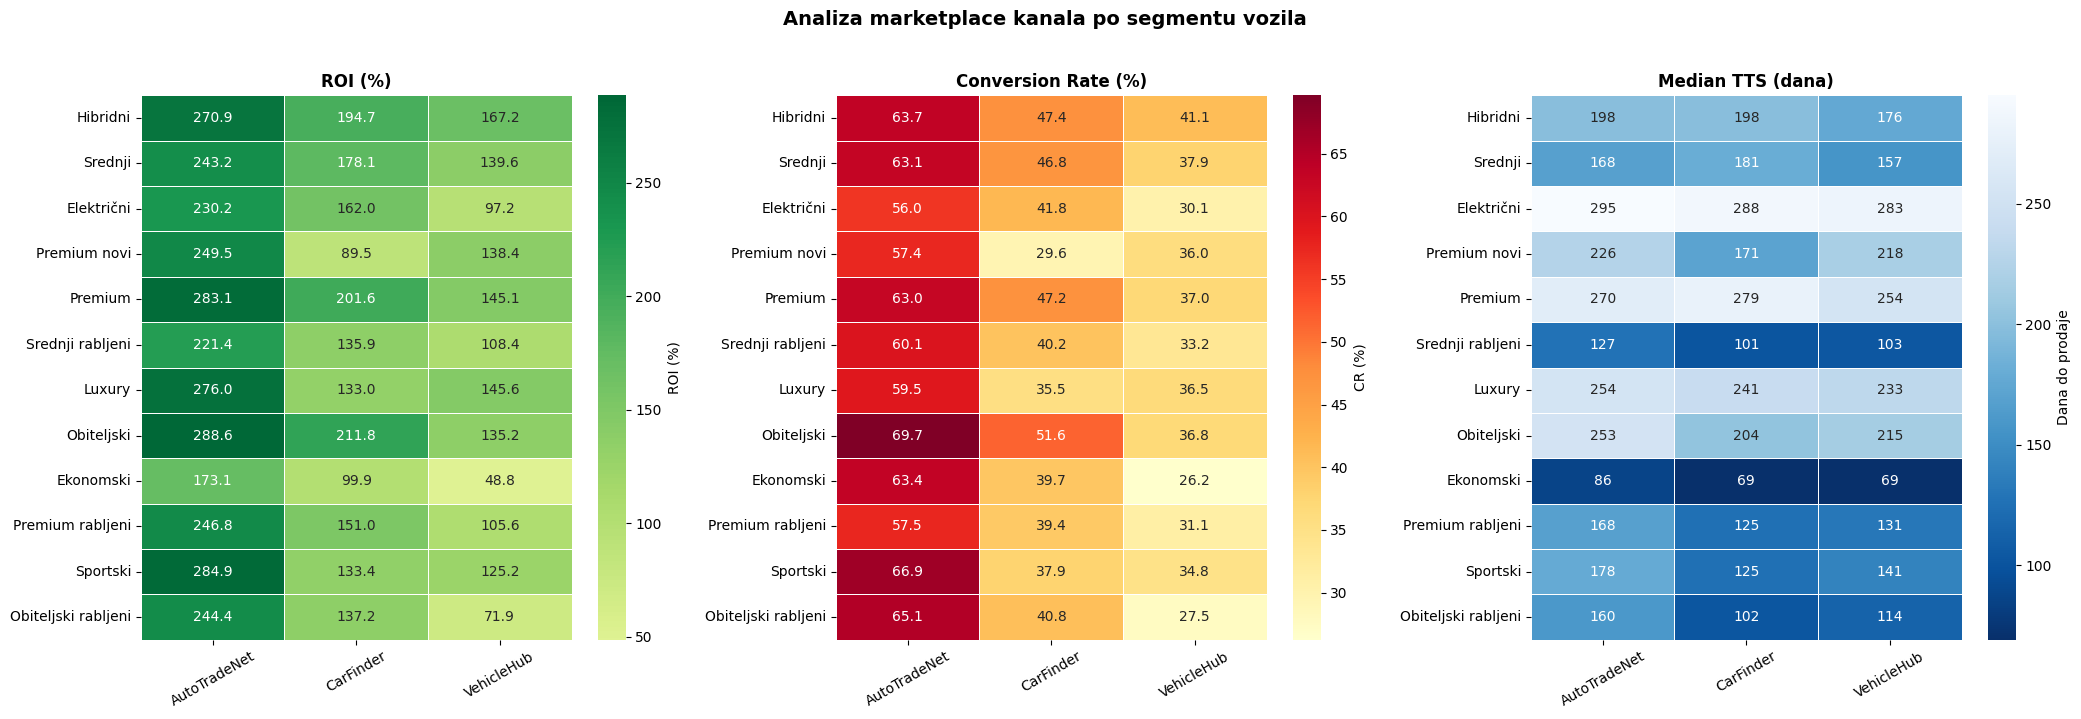

In [ ]:
PRAG_GASENJA = 0
segmenti_sorted = df_r.groupby('SEGMENT')['N'].sum().sort_values(ascending=False).index.tolist()

pivot_roi = df_r.pivot_table(index='SEGMENT', columns='MARKETPLACE', values='ROI_%').reindex(segmenti_sorted)
pivot_cr  = df_r.pivot_table(index='SEGMENT', columns='MARKETPLACE', values='CR_%').reindex(segmenti_sorted)
pivot_tts = df_r.pivot_table(index='SEGMENT', columns='MARKETPLACE', values='TTS_medijan').reindex(segmenti_sorted)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

sns.heatmap(pivot_roi, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'ROI (%)'})
axes[0].set_title('ROI (%)', fontweight='bold', fontsize=12)
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30); axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(pivot_cr, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'CR (%)'})
axes[1].set_title('Conversion Rate (%)', fontweight='bold', fontsize=12)
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30); axes[1].tick_params(axis='y', rotation=0)

sns.heatmap(pivot_tts, annot=True, fmt='.0f', cmap='Blues_r',
            linewidths=0.5, ax=axes[2], cbar_kws={'label': 'Dana do prodaje'})
axes[2].set_title('Median TTS (dana)', fontweight='bold', fontsize=12)
axes[2].set_xlabel(''); axes[2].set_ylabel('')
axes[2].tick_params(axis='x', rotation=30); axes[2].tick_params(axis='y', rotation=0)

plt.suptitle('Analiza marketplace kanala po segmentu vozila', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

AutoTradeNet je financijski najisplativiji kanal (ROI) i ima najveću stopu konverzije (CR), ali vozila na njemu čekaju dulje na prodaju nego na CarFinderu. CarFinder prodaje brže ali s nešto nižim CR-om i ROI-jem. VehicleHub je konzistentno najslabiji na svim dimenzijama osim možda troška.

## 6. Preporuke po segmentu

In [ ]:
print('PREPORUKE PO SEGMENTU')
print(f"{'Segment':<25} {'1. izbor':<16} {'2. izbor':<16} {'3. izbor':<16}")

for segment in segmenti_sorted:
    seg_df = df_r[df_r['SEGMENT'] == segment].sort_values('ROI_%', ascending=False)

    top3 = seg_df['MARKETPLACE'].head(3).tolist()
    top3 += ['---'] * (3 - len(top3))

    print(f"{segment:<25} {top3[0]:<16} {top3[1]:<16} {top3[2]:<16}")

PREPORUKE PO SEGMENTU
Segment                   1. izbor         2. izbor         3. izbor        
Hibridni                  AutoTradeNet     CarFinder        VehicleHub      
Srednji                   AutoTradeNet     CarFinder        VehicleHub      
Električni                AutoTradeNet     CarFinder        VehicleHub      
Premium novi              AutoTradeNet     VehicleHub       CarFinder       
Premium                   AutoTradeNet     CarFinder        VehicleHub      
Srednji rabljeni          AutoTradeNet     CarFinder        VehicleHub      
Luxury                    AutoTradeNet     VehicleHub       CarFinder       
Obiteljski                AutoTradeNet     CarFinder        VehicleHub      
Ekonomski                 AutoTradeNet     CarFinder        VehicleHub      
Premium rabljeni          AutoTradeNet     CarFinder        VehicleHub      
Sportski                  AutoTradeNet     CarFinder        VehicleHub      
Obiteljski rabljeni       AutoTradeNet     CarFinder  

## 7. Business analysis po brandu i cjenovnom segmentu

Kombiniramo conversion rate i prosječnu cijenu u roi_score (70% konverzija + 30% prihod). Ovo nam daje preporuku na razini branda.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
def business_analysis(df_input, group_cols):
    table = (
        df_input.groupby(group_cols, observed=True)
        .agg(
            broj_oglasa=('CONTRACT_STATUS', 'count'),
            broj_ugovora=('CONTRACT_STATUS', 'sum')
        )
        .reset_index()
    )

    table['konverzija_%'] = (table['broj_ugovora'] / table['broj_oglasa'] * 100).round(2)

    avg_price = df_input.groupby(group_cols, observed=True)['PRICE'].mean().reset_index()
    avg_price.columns = list(group_cols) + ['revenue_per_ad']
    table = table.merge(avg_price, on=group_cols, how='left')

    table['pouzdanost'] = pd.cut(
        table['broj_oglasa'],
        bins=[0, 30, 100, 500, float('inf')],
        labels=['Vrlo niska', 'Niska', 'Srednja', 'Visoka']
    )

    scaler = MinMaxScaler()
    score_cols = ['konverzija_%', 'revenue_per_ad']
    scaled = scaler.fit_transform(table[score_cols].fillna(0))
    table['konverzija_score'] = scaled[:, 0]
    table['revenue_score']    = scaled[:, 1]
    table['roi_score'] = (0.7 * table['konverzija_score'] + 0.3 * table['revenue_score']).round(4)

    return table

# Opca analiza po marketplaceu
seg_marketplace = business_analysis(df, ['MARKETPLACE'])
print('ROI score po marketplaceu:')
print(seg_marketplace[['MARKETPLACE', 'broj_oglasa', 'konverzija_%', 'roi_score']].sort_values('roi_score', ascending=False).to_string(index=False))

ROI score po marketplaceu:
 MARKETPLACE  broj_oglasa  konverzija_%  roi_score
   CarFinder        65431         75.74     0.7444
AutoTradeNet       198047         71.57     0.3000
  VehicleHub       261990         72.71     0.1914


In [ ]:
MIN_OGLASA = 30
seg_brand = business_analysis(df, ['BRAND', 'MARKETPLACE'])
seg_brand = seg_brand[seg_brand['broj_oglasa'] >= MIN_OGLASA]
print('Top 20 brand × marketplace kombinacija po roi_score:')
print(seg_brand.sort_values('roi_score', ascending=False).head(20)[['BRAND','MARKETPLACE','broj_oglasa','konverzija_%','roi_score','pouzdanost']].to_string(index=False))

Top 20 brand × marketplace kombinacija po roi_score:
       BRAND  MARKETPLACE  broj_oglasa  konverzija_%  roi_score pouzdanost
ASTON MARTIN AutoTradeNet           39         94.87     0.9001      Niska
ASTON MARTIN   VehicleHub           40         95.00     0.8878      Niska
       ISUZU    CarFinder           50         94.00     0.8284      Niska
       ZEEKR   VehicleHub           79         75.95     0.7733      Niska
       ZEEKR AutoTradeNet           76         75.00     0.7663      Niska
       CUPRA AutoTradeNet           90         90.00     0.7600      Niska
          DS    CarFinder          486         88.68     0.7592    Srednja
   LEAPMOTOR    CarFinder           65         95.38     0.7562      Niska
         BMW    CarFinder         8994         81.30     0.7457     Visoka
       ISUZU AutoTradeNet           94         82.98     0.7422      Niska
       ISUZU   VehicleHub          164         81.10     0.7397    Srednja
     PORSCHE   VehicleHub          190         

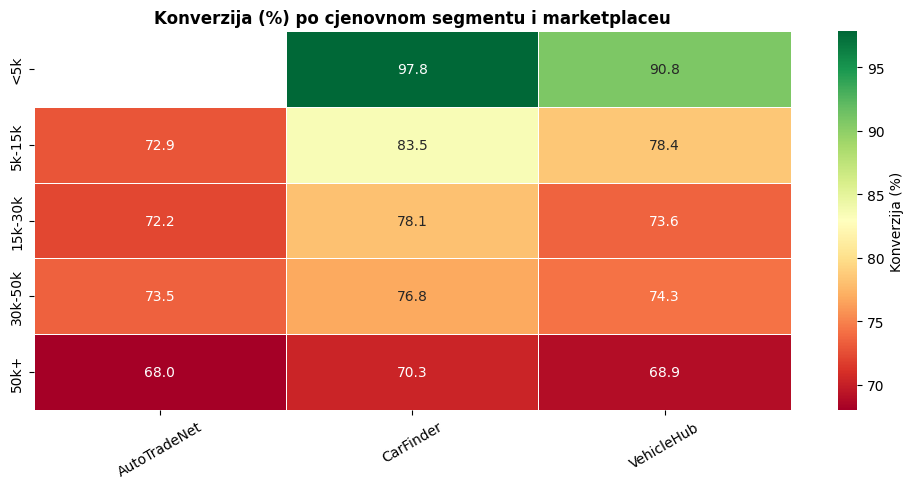


Konverzija po cjenovnom segmentu i marketplaceu:
MARKETPLACE          AutoTradeNet  CarFinder  VehicleHub
PRICE_SEGMENT_BRAND                                     
<5k                           NaN      97.83       90.79
5k-15k                      72.90      83.49       78.40
15k-30k                     72.16      78.09       73.58
30k-50k                     73.46      76.83       74.27
50k+                        68.03      70.29       68.89


In [ ]:
# Po cjenovnom segmentu i marketplaceu
seg_price = business_analysis(df, ['PRICE_SEGMENT_BRAND', 'MARKETPLACE'])
seg_price = seg_price[seg_price['broj_oglasa'] >= MIN_OGLASA]

pivot_brand_cr = seg_price.pivot_table(
    index='PRICE_SEGMENT_BRAND',
    columns='MARKETPLACE',
    values='konverzija_%',
    observed=True
).round(2)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_brand_cr, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Konverzija (%)'})
plt.title('Konverzija (%) po cjenovnom segmentu i marketplaceu', fontweight='bold')
plt.xlabel(''); plt.ylabel('')
plt.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print('\nKonverzija po cjenovnom segmentu i marketplaceu:')
print(pivot_brand_cr)

CarFinder ostvaruje najvišu konverziju u svim cjenovnim segmentima, s posebno visokim vrijednostima kod jeftinijih vozila. Vidljiv je trend pada konverzije s rastom cijene vozila na svim platformama, što sugerira da skuplja vozila zahtijevaju duži proces odlučivanja kod kupaca.

In [ ]:
# Kompletna analiza brand + cjenovni segment + marketplace
seg_full = business_analysis(df, ['BRAND', 'PRICE_SEGMENT_BRAND', 'MARKETPLACE'])
seg_full = seg_full[seg_full['broj_oglasa'] >= MIN_OGLASA]

# Normalizacija unutar grupe brand+segment
group = ['BRAND', 'PRICE_SEGMENT_BRAND']
for col, new_col in [('konverzija_%', 'conv_norm'), ('roi_score', 'roi_norm')]:
    seg_full[new_col] = seg_full.groupby(group, observed=True)[col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
        if x.max() != x.min()
        else pd.Series([1.0] * len(x), index=x.index)
    )

seg_full['final_score'] = (
    0.6 * seg_full['conv_norm'] +
    0.4 * seg_full['roi_norm']
).round(4)

# Najbolji marketplace po svakoj brand + segment kombinaciji
best = (
    seg_full
    .sort_values('final_score', ascending=False)
    .groupby(group, observed=True)
    .first()
    .reset_index()
)

print(f'Broj jedinstvenih brand+segment kombinacija: {len(best)}')
print('\nTop 15 preporuka:')
print(best[['BRAND','PRICE_SEGMENT_BRAND','MARKETPLACE','broj_oglasa','konverzija_%','final_score','pouzdanost']].head(15).to_string(index=False))

Broj jedinstvenih brand+segment kombinacija: 129

Top 15 preporuka:
       BRAND PRICE_SEGMENT_BRAND  MARKETPLACE  broj_oglasa  konverzija_%  final_score pouzdanost
  ALFA ROMEO             15k-30k   VehicleHub          195         61.54          0.6    Srednja
  ALFA ROMEO             30k-50k    CarFinder          190         71.05          1.0    Srednja
  ALFA ROMEO                50k+   VehicleHub         1361         71.49          1.0     Visoka
ASTON MARTIN                50k+   VehicleHub           40         95.00          0.6      Niska
        AUDI              5k-15k   VehicleHub           32         93.75          1.0      Niska
        AUDI             15k-30k AutoTradeNet          277         74.01          1.0    Srednja
        AUDI             30k-50k    CarFinder          215         74.88          1.0    Srednja
        AUDI                50k+ AutoTradeNet          318         66.04          1.0    Srednja
         BMW              5k-15k    CarFinder           32 

## 8. Sezonska analiza — kada oglašavati?

In [ ]:
df['MJESEC']  = df['DATE_START'].dt.month
df['KVARTAL'] = df['DATE_START'].dt.quarter
df['GODISNJE_DOBA'] = df['MJESEC'].map({
    12: 'Zima',     1: 'Zima',     2: 'Zima',
    3:  'Proljece', 4: 'Proljece', 5: 'Proljece',
    6:  'Ljeto',    7: 'Ljeto',    8: 'Ljeto',
    9:  'Jesen',   10: 'Jesen',   11: 'Jesen'
})

print('Broj oglasa po godisnjim dobima:')
print(df['GODISNJE_DOBA'].value_counts())

Broj oglasa po godisnjim dobima:
GODISNJE_DOBA
Ljeto       272897
Zima        204366
Proljece    195601
Jesen       195164
Name: count, dtype: int64


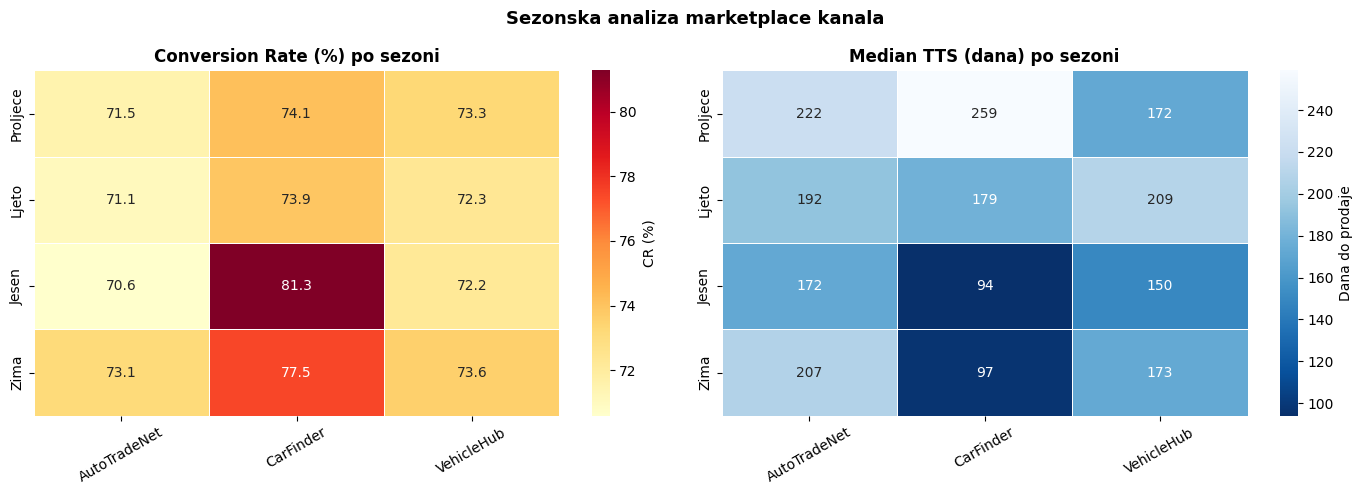

In [ ]:
redoslijed = ['Proljece', 'Ljeto', 'Jesen', 'Zima']

cr_sezona = df.groupby(['GODISNJE_DOBA', 'MARKETPLACE'])['CONTRACT_STATUS'].mean() * 100
pivot_sezona_cr = cr_sezona.unstack('MARKETPLACE').reindex(redoslijed).round(2)

sold['GODISNJE_DOBA'] = sold['DATE_START'].dt.month.map({
    12: 'Zima', 1: 'Zima', 2: 'Zima',
    3: 'Proljece', 4: 'Proljece', 5: 'Proljece',
    6: 'Ljeto', 7: 'Ljeto', 8: 'Ljeto',
    9: 'Jesen', 10: 'Jesen', 11: 'Jesen'
})
pivot_sezona_tts = sold.groupby(['GODISNJE_DOBA', 'MARKETPLACE'])['DAYS_TO_SELL'].median().unstack('MARKETPLACE').reindex(redoslijed).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_sezona_cr, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'CR (%)'})
axes[0].set_title('Conversion Rate (%) po sezoni', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(pivot_sezona_tts, annot=True, fmt='.0f', cmap='Blues_r',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Dana do prodaje'})
axes[1].set_title('Median TTS (dana) po sezoni', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Sezonska analiza marketplace kanala', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

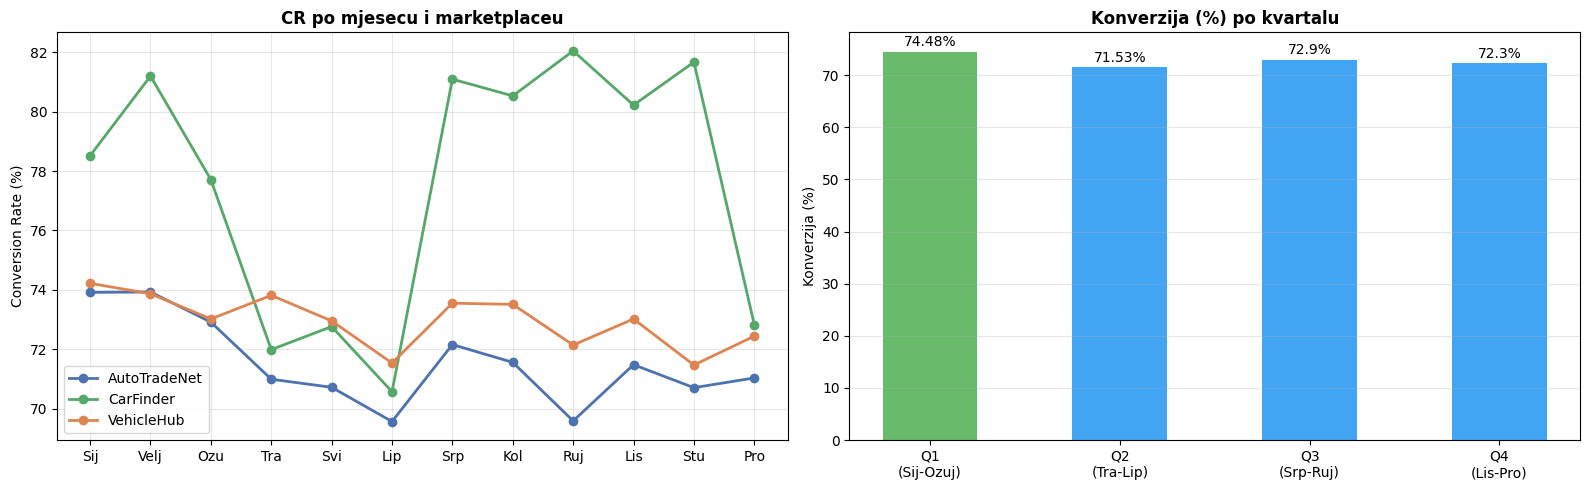

In [ ]:
# Linijski graf CR po mjesecu
cr_mjesec = df.groupby(['MJESEC', 'MARKETPLACE'])['CONTRACT_STATUS'].mean() * 100
pivot_mjesec = cr_mjesec.unstack('MARKETPLACE')

# Kvartal analiza
kvartal_data = df.groupby('KVARTAL').agg(
    broj_oglasa=('CONTRACT_STATUS', 'count'),
    broj_ugovora=('CONTRACT_STATUS', 'sum')
).reset_index()
kvartal_data['konverzija_%'] = (kvartal_data['broj_ugovora'] / kvartal_data['broj_oglasa'] * 100).round(2)
kvartal_data['KVARTAL_IME'] = kvartal_data['KVARTAL'].map({
    1: 'Q1\n(Sij-Ozuj)', 2: 'Q2\n(Tra-Lip)',
    3: 'Q3\n(Srp-Ruj)', 4: 'Q4\n(Lis-Pro)'
})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

boje_mp = {'AutoTradeNet': '#4C72B0', 'CarFinder': '#55A868', 'VehicleHub': '#DD8452'}
for mp in pivot_mjesec.columns:
    axes[0].plot(pivot_mjesec.index, pivot_mjesec[mp], marker='o',
                label=mp, color=boje_mp.get(mp), linewidth=2)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(['Sij','Velj','Ozu','Tra','Svi','Lip','Srp','Kol','Ruj','Lis','Stu','Pro'])
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_title('CR po mjesecu i marketplaceu', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

boje_kv = ['#4CAF50' if x == kvartal_data['konverzija_%'].max() else '#2196F3'
           for x in kvartal_data['konverzija_%']]
bars = axes[1].bar(kvartal_data['KVARTAL_IME'], kvartal_data['konverzija_%'],
                   color=boje_kv, alpha=0.85, width=0.5)
for bar, val in zip(bars, kvartal_data['konverzija_%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Konverzija (%) po kvartalu', fontweight='bold')
axes[1].set_ylabel('Konverzija (%)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Na temelju grafova mozemo zakljuciti da je najbolje vrijeme za prodaju automobila zima, kada se događa najviše prodaja. Izvor koji potvrđuje našu analizu: https://www.coxautoinc.com/insights/q1-2026-muvvi/,
https://fred.stlouisfed.org/series/TOTALSA,
https://hr.ecarstrade.com/blog/seasonality-in-car-sales

## 10. Analiza po starosti i kilometražnim razredima

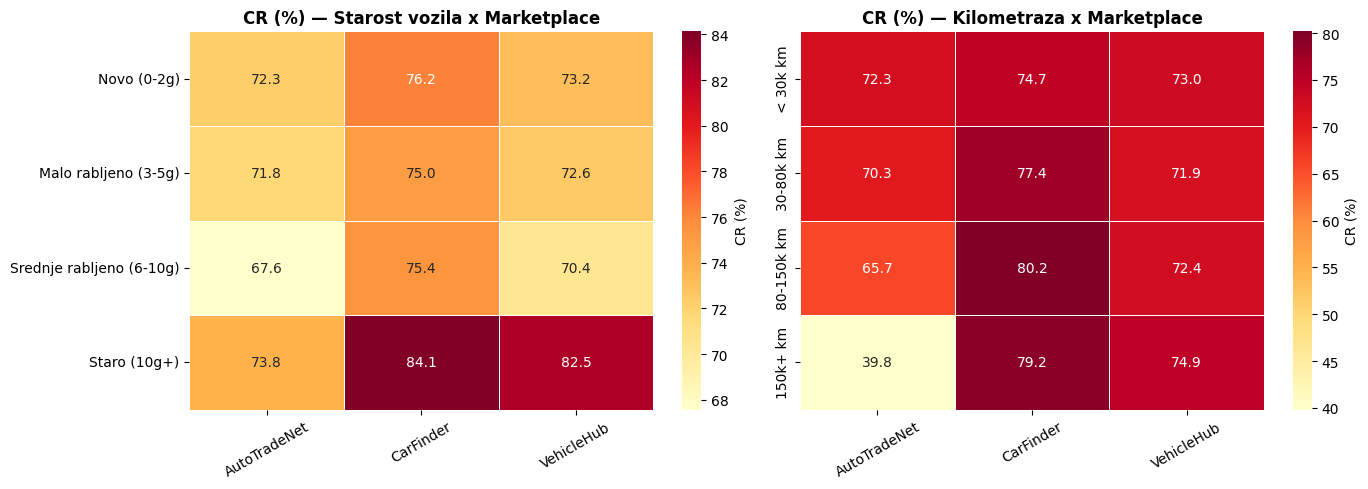

In [ ]:
df['STAROST_RAZRED'] = pd.cut(df['AGE'],
    bins=[-1, 2, 5, 10, 100],
    labels=['Novo (0-2g)', 'Malo rabljeno (3-5g)', 'Srednje rabljeno (6-10g)', 'Staro (10g+)']
)
df['KM_RAZRED'] = pd.cut(df['CURRENT_MILEAGE'],
    bins=[-1, 30000, 80000, 150000, 999999],
    labels=['< 30k km', '30-80k km', '80-150k km', '150k+ km']
)

pivot_starost = df.groupby(['STAROST_RAZRED', 'MARKETPLACE'], observed=True)['CONTRACT_STATUS'].mean() * 100
pivot_starost = pivot_starost.unstack('MARKETPLACE').round(2)
pivot_km = df.groupby(['KM_RAZRED', 'MARKETPLACE'], observed=True)['CONTRACT_STATUS'].mean() * 100
pivot_km = pivot_km.unstack('MARKETPLACE').round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pivot_starost, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'CR (%)'})
axes[0].set_title('CR (%) — Starost vozila x Marketplace', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(pivot_km, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'CR (%)'})
axes[1].set_title('CR (%) — Kilometraza x Marketplace', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Analiza konverzije prema starosti vozila pokazuje da CarFinder i VehicleHub ostvaruju najvišu konverziju kod starijih vozila (10g+), dok AutoTradeNet ne prati taj trend. Kod kilometraže, AutoTradeNet drastično pada na vozilima s više od 150k km na svega 39.8%, dok CarFinder ostaje stabilan s 79.2%, što upućuje na to da AutoTradeNet privlači kupce orijentirane prema novijim i niskokilometražnim vozilima, a CarFinder zadržava visoku konverziju neovisno o starosti i prijeđenoj kilometraži vozila.

## 11. Lead rate i offer rate po segmentu

Koliko oglasa dođe do faze leada/offera, mjeri kvalitetu prometa po kanalu.

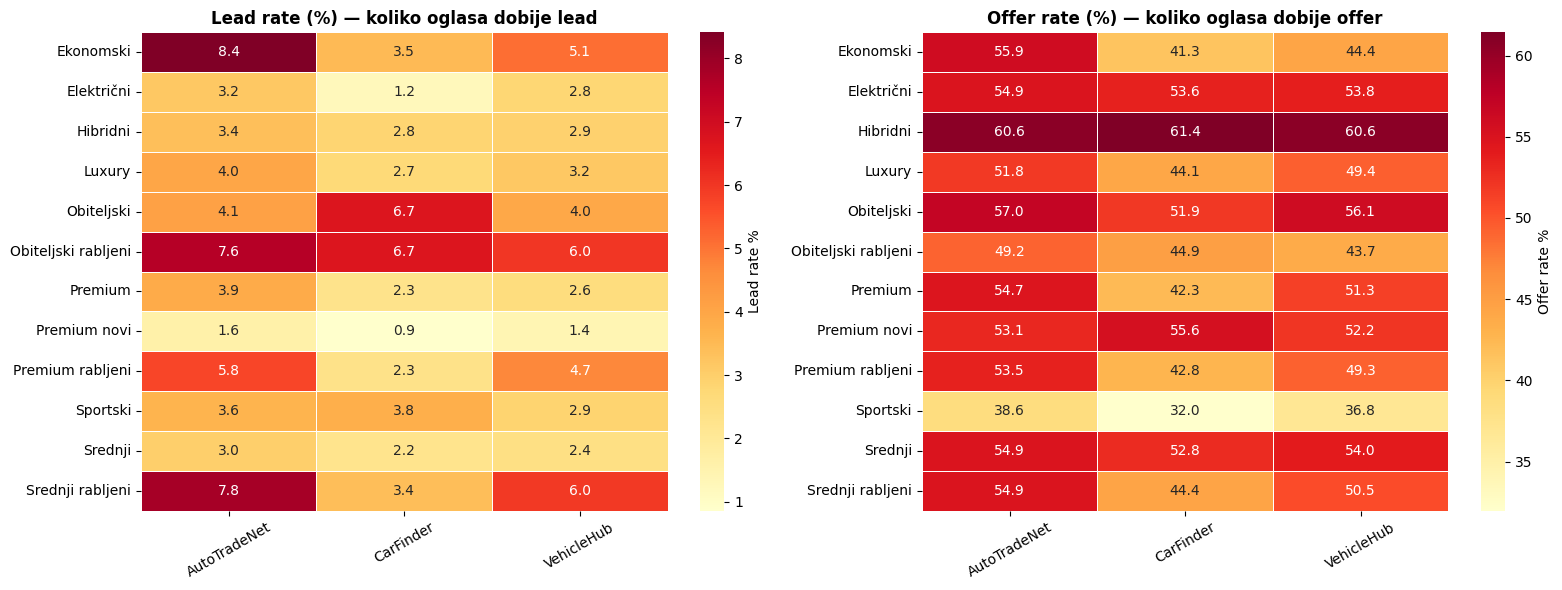


Lead rate % po segmentu i marketplaceu:
MARKETPLACE          AutoTradeNet  CarFinder  VehicleHub
SEGMENT                                                 
Ekonomski                    8.41       3.49        5.10
Električni                   3.18       1.22        2.78
Hibridni                     3.38       2.84        2.93
Luxury                       3.99       2.70        3.17
Obiteljski                   4.11       6.69        3.95
Obiteljski rabljeni          7.56       6.67        6.01
Premium                      3.89       2.29        2.59
Premium novi                 1.62       0.86        1.42
Premium rabljeni             5.75       2.31        4.70
Sportski                     3.65       3.77        2.89
Srednji                      3.00       2.22        2.44
Srednji rabljeni             7.81       3.41        5.96


In [ ]:
offer_rate = df.groupby(['MARKETPLACE', 'SEGMENT']).agg(
    Ukupno    = ('CONTRACT_STATUS', 'count'),
    Ima_offer = ('OFFER_STATUS', lambda x: x.notna().sum()),
    Ima_lead  = ('LEAD_STATUS',  lambda x: x.notna().sum()),
).reset_index()

offer_rate['Offer_rate_%'] = (offer_rate['Ima_offer'] / offer_rate['Ukupno'] * 100).round(2)
offer_rate['Lead_rate_%']  = (offer_rate['Ima_lead']  / offer_rate['Ukupno'] * 100).round(2)

pivot_offer_rate = offer_rate.pivot_table(index='SEGMENT', columns='MARKETPLACE', values='Offer_rate_%')
pivot_lead_rate  = offer_rate.pivot_table(index='SEGMENT', columns='MARKETPLACE', values='Lead_rate_%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pivot_lead_rate, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Lead rate %'})
axes[0].set_title('Lead rate (%) — koliko oglasa dobije lead', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30); axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(pivot_offer_rate, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Offer rate %'})
axes[1].set_title('Offer rate (%) — koliko oglasa dobije offer', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30); axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

print('\nLead rate % po segmentu i marketplaceu:')
print(pivot_lead_rate.round(2))

AutoTradeNet generira najviše leadova u većini segmenata, posebno kod Srednji rabljeni (7.8%) i Obiteljski rabljeni (7.6%). Kada se promatra offer rate, razlike između platformi se smanjuju, a Hibridni segment ostvaruje najviše vrijednosti na svim platformama (~60%). Sportski segment bilježi najniži offer rate (32-38%), što sugerira da kupci sportskih vozila češće istražuju nego što daju konkretne ponude.

## 13. Analiza po tipu karoserije

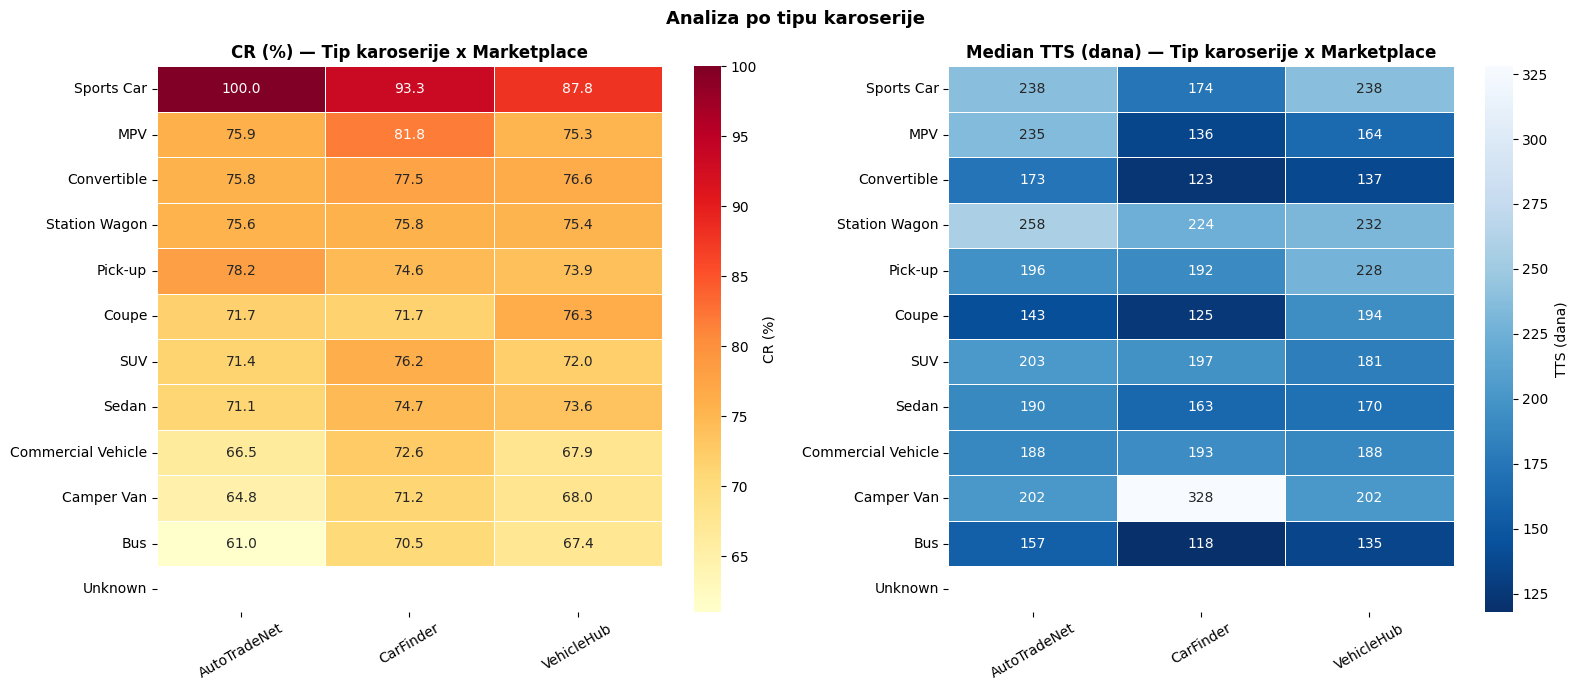

In [ ]:
pivot_body = df.groupby(['BODY_TYPE', 'MARKETPLACE'])['CONTRACT_STATUS'].mean() * 100
pivot_body = pivot_body.unstack('MARKETPLACE').round(2)
pivot_body['prosjek'] = pivot_body.mean(axis=1)
pivot_body = pivot_body.sort_values('prosjek', ascending=False).drop(columns='prosjek')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pivot_body, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'CR (%)'})
axes[0].set_title('CR (%) — Tip karoserije x Marketplace', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('')
axes[0].tick_params(axis='x', rotation=30); axes[0].tick_params(axis='y', rotation=0)

pivot_body_tts = sold.groupby(['BODY_TYPE', 'MARKETPLACE'])['DAYS_TO_SELL'].median()
pivot_body_tts = pivot_body_tts.unstack('MARKETPLACE').round(1)
pivot_body_tts = pivot_body_tts.reindex(pivot_body.index)

sns.heatmap(pivot_body_tts, annot=True, fmt='.0f', cmap='Blues_r',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'TTS (dana)'})
axes[1].set_title('Median TTS (dana) — Tip karoserije x Marketplace', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30); axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Analiza po tipu karoserije', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Sports Car ostvaruje najviši CR na svim platformama (88-100%) što je logično s obzirom na njihove cijene, no vrijednost od 100% na AutoTradeNetu treba uzeti s oprezom zbog malog uzorka. CarFinder se ističe kraćim vremenom prodaje u većini kategorija karoserije, dok komercijalna vozila i Bus bilježe najniže CR vrijednosti. Station Wagon najdulje čeka na prodaju bez obzira na platformu (224-258 dana).

## 14. Preporuka marketplace kanala za konkretno vozilo

Upiši gorivo, tip, cijenu, starost i km — funkcija određuje segment i preporučuje optimalni kanal.

In [ ]:
def preporuci(gorivo, tip, cijena, age, km):
    fuel_map_fn = {
        'Electric': 'električni',
        'Plug-in Hybrid': 'hibrid', 'Hybrid': 'hibrid',
        'Mild Hybrid': 'benzin', 'Diesel': 'diesel',
        'Petrol': 'benzin', 'Gas': 'ostalo', 'Other': 'ostalo'
    }
    body_map_fn = {
        'SUV': 'suv', 'MPV': 'obiteljski', 'Station Wagon': 'obiteljski',
        'Sedan': 'gradski', 'Coupe': 'gradski',
        'Convertible': 'sportski', 'Sports Car': 'sportski',
        'Commercial Vehicle': 'komercijalni', 'Pick-up': 'komercijalni',
        'Bus': 'komercijalni', 'Camper Van': 'komercijalni'
    }

    gorivo_kat  = fuel_map_fn.get(gorivo, 'ostalo')
    body_kat    = body_map_fn.get(tip, 'ostalo')
    je_novo     = age <= 2 and km <= 30000
    je_rabljeno = age > 5 or km > 80000

    if cijena <= 15000:   price_kat = 'ekonomski'
    elif cijena <= 40000: price_kat = 'srednji'
    elif cijena <= 70000: price_kat = 'premium'
    else:                 price_kat = 'luxury'

    if gorivo_kat == 'električni':   segment = 'Električni'
    elif gorivo_kat == 'hibrid':     segment = 'Hibridni'
    elif price_kat == 'luxury':      segment = 'Luxury'
    elif body_kat == 'sportski' and price_kat in ['srednji','premium']: segment = 'Sportski'
    elif price_kat == 'premium':
        if je_novo:        segment = 'Premium novi'
        elif je_rabljeno:  segment = 'Premium rabljeni'
        else:              segment = 'Premium'
    elif price_kat == 'srednji':
        if body_kat == 'obiteljski':
            segment = 'Obiteljski rabljeni' if je_rabljeno else 'Obiteljski'
        else:
            segment = 'Srednji rabljeni' if je_rabljeno else 'Srednji'
    else: segment = 'Ekonomski'

    seg_df = df_r[df_r['SEGMENT'] == segment].copy()

    if seg_df.empty:
        print(f'Segment "{segment}" nije pronađen!')
        return

    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()

    if len(seg_df) > 1:
        seg_df[['roi_norm', 'cr_norm', 'tts_norm']] = scaler.fit_transform(
            seg_df[['ROI_%', 'CR_%', 'TTS_medijan']].fillna(0)
        )
        seg_df['tts_norm'] = 1 - seg_df['tts_norm']
        seg_df['score'] = (
            0.33 * seg_df['roi_norm'] +
            0.33 * seg_df['cr_norm'] +
            0.33 * seg_df['tts_norm']
        )
    else:
        seg_df['score'] = 1.0

    seg_df = seg_df.sort_values('score', ascending=False)

    print(f"\n{'='*62}")
    print(f"  Auto: {gorivo} | {tip} | {cijena:,.0f} € | {age}g | {km:,} km")
    print(f"  Segment: {segment}")
    print(f"{'='*62}")
    print(f"  {'Marketplace':<15} {'CR%':>6} {'TTS':>6} {'ROI%':>7} {'Trosak':>10} {'Score':>7}")
    print(f"  {'-'*60}")
    for i, (_, row) in enumerate(seg_df.iterrows()):
        oznaka  = ' ★' if i == 0 else ''
        tts_str = f"{row['TTS_medijan']:.0f}d" if pd.notna(row['TTS_medijan']) else 'N/A'
        print(f"  {row['MARKETPLACE']:<15} {row['CR_%']:>5.1f}% "
              f"{tts_str:>6} {row['ROI_%']:>6.1f}% "
              f"{row['Trosak_ukupno_EUR']:>9.0f}€ "
              f"{row['score']:>6.3f}{oznaka}")
    print(f"{'='*62}\n")


# Primjeri
preporuci('Diesel', 'SUV', 35000, age=3, km=45000)
preporuci('Diesel', 'SUV', 35000, age=8, km=120000)
preporuci('Electric', 'Sedan', 45000, age=1, km=8000)
preporuci('Petrol', 'Coupe', 28000, age=4, km=60000)
preporuci('Hybrid', 'MPV', 25000, age=6, km=90000)


  Auto: Diesel | SUV | 35,000 € | 3g | 45,000 km
  Segment: Srednji
  Marketplace        CR%    TTS    ROI%     Trosak   Score
  ------------------------------------------------------------
  AutoTradeNet     63.1%   168d  243.2%       359€  0.817 ★
  VehicleHub       37.9%   157d  139.6%       309€  0.400
  CarFinder        46.8%   181d  178.1%       329€  0.216


  Auto: Diesel | SUV | 35,000 € | 8g | 120,000 km
  Segment: Srednji rabljeni
  Marketplace        CR%    TTS    ROI%     Trosak   Score
  ------------------------------------------------------------
  AutoTradeNet     60.1%   127d  221.4%       339€  0.600 ★
  CarFinder        40.2%   101d  135.9%       309€  0.553
  VehicleHub       33.2%   103d  108.4%       289€  0.369


  Auto: Electric | Sedan | 45,000 € | 1g | 8,000 km
  Segment: Električni
  Marketplace        CR%    TTS    ROI%     Trosak   Score
  ------------------------------------------------------------
  AutoTradeNet     56.0%   295d  230.2%       506€  0.600

# 15. Dodatno

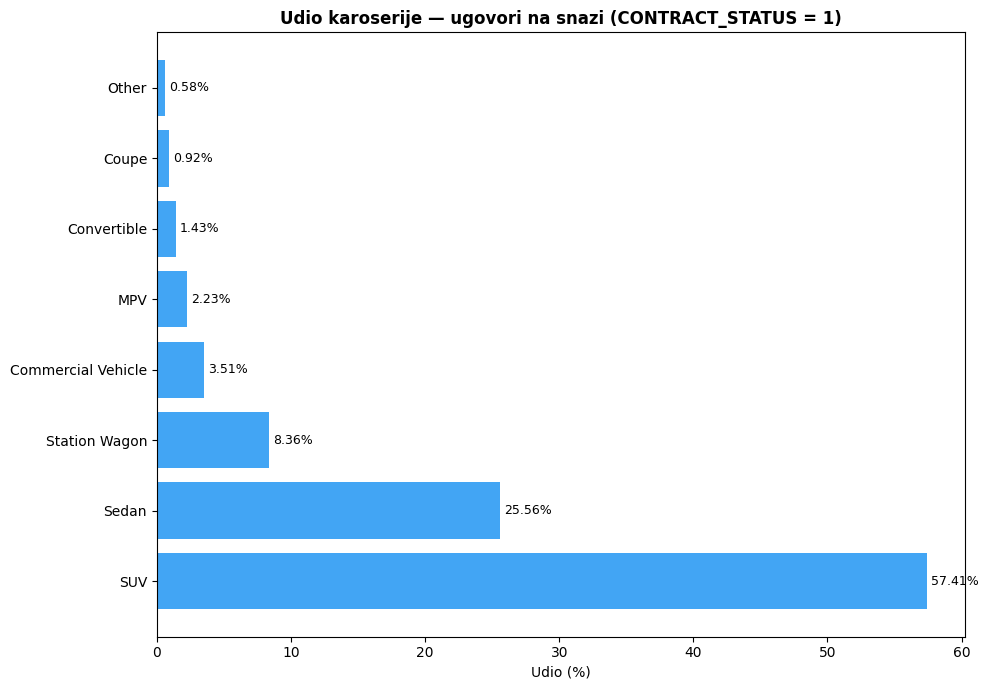

In [ ]:

df_active = df[df['CONTRACT_STATUS'] == 1]

body_counts = df_active['BODY_TYPE'].value_counts()
body_pct    = (body_counts / body_counts.sum() * 100).round(2)

body_pct_clean = body_pct.copy()
body_pct_clean['Other'] = sum([
    body_pct_clean.get(k, 0)
    for k in ['Sports Car', 'Pick-up', 'Bus', 'Camper Van', 'Unknown']
])
body_pct_clean = body_pct_clean.drop(
    ['Sports Car', 'Pick-up', 'Bus', 'Camper Van', 'Unknown'],
    errors='ignore'
)

body_compare = pd.DataFrame({
    'Tvoji podaci (%)': body_pct_clean,
}).round(2)

fig, ax = plt.subplots(figsize=(10, 7))

categories = body_compare.index
y = range(len(categories))

ax.barh(list(y), body_compare['Tvoji podaci (%)'], color='#2196F3', alpha=0.85)
ax.set_yticks(list(y))
ax.set_yticklabels(categories)
ax.set_title('Udio karoserije — ugovori na snazi (CONTRACT_STATUS = 1)', fontweight='bold')
ax.set_xlabel('Udio (%)')
for i, val in enumerate(body_compare['Tvoji podaci (%)']):
    ax.text(val + 0.3, i, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Na preporuku mentora proucili smo stanje prodaja automobila u datasetu i ptvrdili sa više izvora da SUV dominira u Europi: https://www.carvertical.com/en/blog/car-body-types-europeans-prefer, https://www.motor1.com/news/783371/suv-sales-dominate-europe/